In [72]:
import os
import pandas as pd
import numpy as np
# from scipy.integrate import cumulative_trapezoid
import re
import matplotlib.pyplot as plt
import matplotlib.cm as cm  
import numpy as np
from impedance.models.circuits import CustomCircuit
from impedance.visualization import plot_nyquist
from tqdm.auto import tqdm

/Users/sushankmishra/Desktop/MTP_Materials/EIS Fitting/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Base Set of Files

In [2]:
base_path = './LiPo Battery LP-503562-IS-3 EIS, Capacity, ECM Data'

# List all files matching stddischarge format
batteries = ['LiPO_1', 'LiPO_2', 'LiPO_3','LiPO_4', 'LiPO_5']
batteries_files = []
for battery in batteries:
    folder_path = os.path.join(base_path, battery, 'EIS_Charge_discharge')
    files_stddischarge = [f for f in os.listdir(folder_path) if re.match(r'0_\d+_1_stddischarge\.csv', f)]
    files_stddischarge.sort(key=lambda x: int(re.search(r'0_(\d+)_1_stddischarge\.csv', x).group(1)))
    batteries_files.append({'battery':battery, 'files':files_stddischarge})
batteries_files_df = pd.DataFrame(batteries_files)
# Sort files numerically by cycle number
batteries_files_df.sort_values(by='battery')


,battery,files
0,LiPO_1,"[0_0_1_stddischarge.csv, 0_45_1_stddischarge.c..."
1,LiPO_2,"[0_0_1_stddischarge.csv, 0_20_1_stddischarge.c..."
2,LiPO_3,"[0_0_1_stddischarge.csv, 0_45_1_stddischarge.c..."
3,LiPO_4,"[0_0_1_stddischarge.csv, 0_45_1_stddischarge.c..."
4,LiPO_5,"[0_0_1_stddischarge.csv, 0_45_1_stddischarge.c..."


## Capacity at different Cycles

In [3]:
cycle_vs_capacity = []
for battery in batteries:
    folder_path = os.path.join(base_path, battery, 'EIS_Charge_discharge')
    for files in batteries_files_df[batteries_files_df['battery'] == battery]['files']:
        for file in files:
            cycle = int(file.split('_')[1])
            df = pd.read_csv(os.path.join(folder_path, file), header=None, names=['Time', 'Voltage', 'Current'],delimiter='\t')
            df = df.apply(pd.to_numeric, errors='coerce')
            df = df.dropna()
            df = df.sort_values(by='Time')

            time = df['Time'].values  # in seconds
            current = df['Current'].values  # in A
            capacity_As = np.trapezoid(current, time)
            capacity_Ah = capacity_As / 3600
            cycle_vs_capacity.append({
                "Battery": battery,
                "Cycle": cycle,
                "Discharge_Capacity_Ah": capacity_Ah
            })
cycle_vs_capacity_df = pd.DataFrame(cycle_vs_capacity)
cycle_vs_capacity_df = cycle_vs_capacity_df.sort_values(by=['Battery','Cycle'])
cycle_vs_capacity_df

,Battery,Cycle,Discharge_Capacity_Ah
0,LiPO_1,0,3.664491
1,LiPO_1,45,3.556919
2,LiPO_1,90,3.408802
3,LiPO_1,116,3.341066
4,LiPO_1,135,3.271616
5,LiPO_1,180,2.935235
6,LiPO_1,204,2.841165
7,LiPO_2,0,3.549720
8,LiPO_2,20,3.537430
9,LiPO_2,40,3.507533


## SoH at different Cycles

In [4]:
cycle_vs_capacity_df['SoH'] = np.nan
for battery in batteries:
    battery_df = cycle_vs_capacity_df[cycle_vs_capacity_df['Battery'] == battery].sort_values(by='Cycle')
    initial_capacity = battery_df.iloc[0]['Discharge_Capacity_Ah']
    soh_values = battery_df['Discharge_Capacity_Ah'] / initial_capacity
    cycle_vs_capacity_df.loc[battery_df.index, 'SoH'] = soh_values

cycle_vs_capacity_df
# for i, row in cycle_vs_capacity_df.iterrows():
#     print(f"Cycle {int(row['Cycle']):>3}: Capacity = {-1*row['Discharge_Capacity_Ah']:.4f} Ah, SoH = {row['SoH']:.2%}")

,Battery,Cycle,Discharge_Capacity_Ah,SoH
0,LiPO_1,0,3.664491,1.000000
1,LiPO_1,45,3.556919,0.970645
2,LiPO_1,90,3.408802,0.930225
3,LiPO_1,116,3.341066,0.911741
4,LiPO_1,135,3.271616,0.892789
5,LiPO_1,180,2.935235,0.800994
6,LiPO_1,204,2.841165,0.775323
7,LiPO_2,0,3.549720,1.000000
8,LiPO_2,20,3.537430,0.996538
9,LiPO_2,40,3.507533,0.988115


# SoC for all EIS Files

In [19]:
cycle_vs_SoC_vs_file = []
for battery in batteries:
    folder_path = os.path.join(base_path, battery, 'EIS_Charge_discharge')
    files_EIS = [f for f in os.listdir(folder_path) if re.match(r'EIS+_\d', f)]
    files_EIS.sort(key=lambda x: int(x.split('_')[1]))
    for folder in files_EIS:
        folder_path_EIS = os.path.join(folder_path, folder)
        if folder.startswith('EIS_') and os.path.isdir(folder_path_EIS):
            cycle_number = int(folder.split('_')[1])
            files_EIS_folder = [f for f in os.listdir(folder_path_EIS)]
            soc_df = None
            # Get SoC from cycle_vs_capacity_df
            for f in os.listdir(folder_path_EIS):
                if f.endswith('SOC.csv'):
                    soc_file_path = os.path.join(folder_path_EIS, f)
                    soc_df = pd.read_csv(soc_file_path, header=None, names=['SoC'], delimiter='\t')
                    soc_df = soc_df.apply(pd.to_numeric, errors='coerce')
                    soc_df = soc_df.dropna()
                    soc_df['index'] = range(len(soc_df))
                    break
            for f in os.listdir(folder_path_EIS):
                if f.endswith('.csv') and not f.endswith('SOC.csv'):
                    eis_file_path = os.path.join(folder_path_EIS, f)
                    a = int(f.split('_')[0])
                    cycle_vs_SoC_vs_file.append({
                        "Battery": battery,
                        "Cycle": cycle_number,
                        "EIS_File": eis_file_path,
                        "SoC": soc_df[soc_df['index'] == a]['SoC'].values[0]
                    })
            # int(folder.split('_')[0])
cycle_vs_SoC_vs_file_df = pd.DataFrame(cycle_vs_SoC_vs_file)
cycle_vs_SoC_vs_file_df

,Battery,Cycle,EIS_File,SoC
0,LiPO_1,0,"./LiPo Battery LP-503562-IS-3 EIS, Capacity, E...",0.590103
1,LiPO_1,0,"./LiPo Battery LP-503562-IS-3 EIS, Capacity, E...",0.687775
2,LiPO_1,0,"./LiPo Battery LP-503562-IS-3 EIS, Capacity, E...",0.492432
3,LiPO_1,0,"./LiPo Battery LP-503562-IS-3 EIS, Capacity, E...",0.395031
4,LiPO_1,0,"./LiPo Battery LP-503562-IS-3 EIS, Capacity, E...",0.883118
...,...,...,...,...
544,LiPO_5,540,"./LiPo Battery LP-503562-IS-3 EIS, Capacity, E...",0.070080
545,LiPO_5,540,"./LiPo Battery LP-503562-IS-3 EIS, Capacity, E...",0.690026
546,LiPO_5,540,"./LiPo Battery LP-503562-IS-3 EIS, Capacity, E...",0.534825
547,LiPO_5,540,"./LiPo Battery LP-503562-IS-3 EIS, Capacity, E...",0.845228


# Final Dataframe

In [20]:
all_battery_data = pd.merge(cycle_vs_SoC_vs_file_df, cycle_vs_capacity_df, on=['Battery', 'Cycle'], how='left')
all_battery_data["Modified SoC"] = np.round(all_battery_data["SoC"],1)
all_battery_data.sort_values(by=['Battery','Cycle','Modified SoC'],inplace=True)
all_battery_data

,Battery,Cycle,EIS_File,SoC,Discharge_Capacity_Ah,SoH,Modified SoC
5,LiPO_1,0,"./LiPo Battery LP-503562-IS-3 EIS, Capacity, E...",0.102017,3.664491,1.000000,0.1
9,LiPO_1,0,"./LiPo Battery LP-503562-IS-3 EIS, Capacity, E...",0.199689,3.664491,1.000000,0.2
8,LiPO_1,0,"./LiPo Battery LP-503562-IS-3 EIS, Capacity, E...",0.297359,3.664491,1.000000,0.3
3,LiPO_1,0,"./LiPo Battery LP-503562-IS-3 EIS, Capacity, E...",0.395031,3.664491,1.000000,0.4
2,LiPO_1,0,"./LiPo Battery LP-503562-IS-3 EIS, Capacity, E...",0.492432,3.664491,1.000000,0.5
...,...,...,...,...,...,...,...
543,LiPO_5,540,"./LiPo Battery LP-503562-IS-3 EIS, Capacity, E...",0.379624,2.250180,0.611831,0.4
546,LiPO_5,540,"./LiPo Battery LP-503562-IS-3 EIS, Capacity, E...",0.534825,2.250180,0.611831,0.5
545,LiPO_5,540,"./LiPo Battery LP-503562-IS-3 EIS, Capacity, E...",0.690026,2.250180,0.611831,0.7
547,LiPO_5,540,"./LiPo Battery LP-503562-IS-3 EIS, Capacity, E...",0.845228,2.250180,0.611831,0.8


In [ ]:
# fig, ax = plt.subplots(figsize=(10, 8))
SoC_cohorts = all_battery_data["Modified SoC"].unique()
print(SoC_cohorts)

[0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  0. ]


# Graphical Analysis

## Visual Analysis

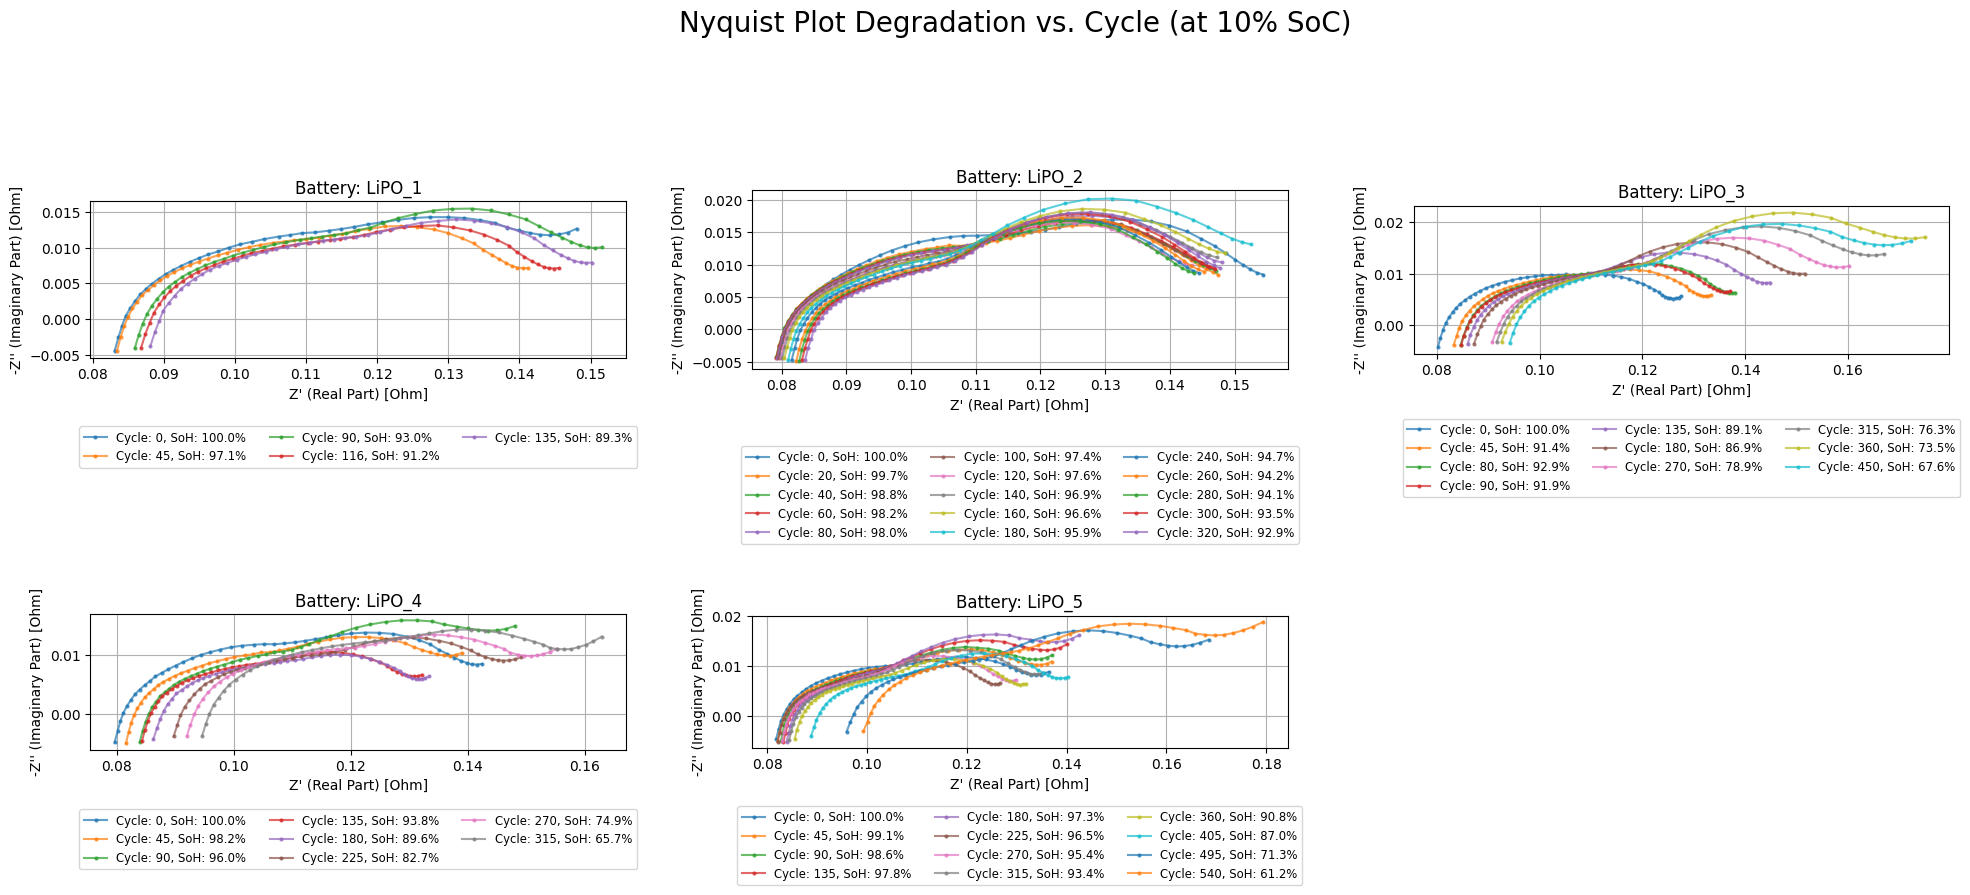

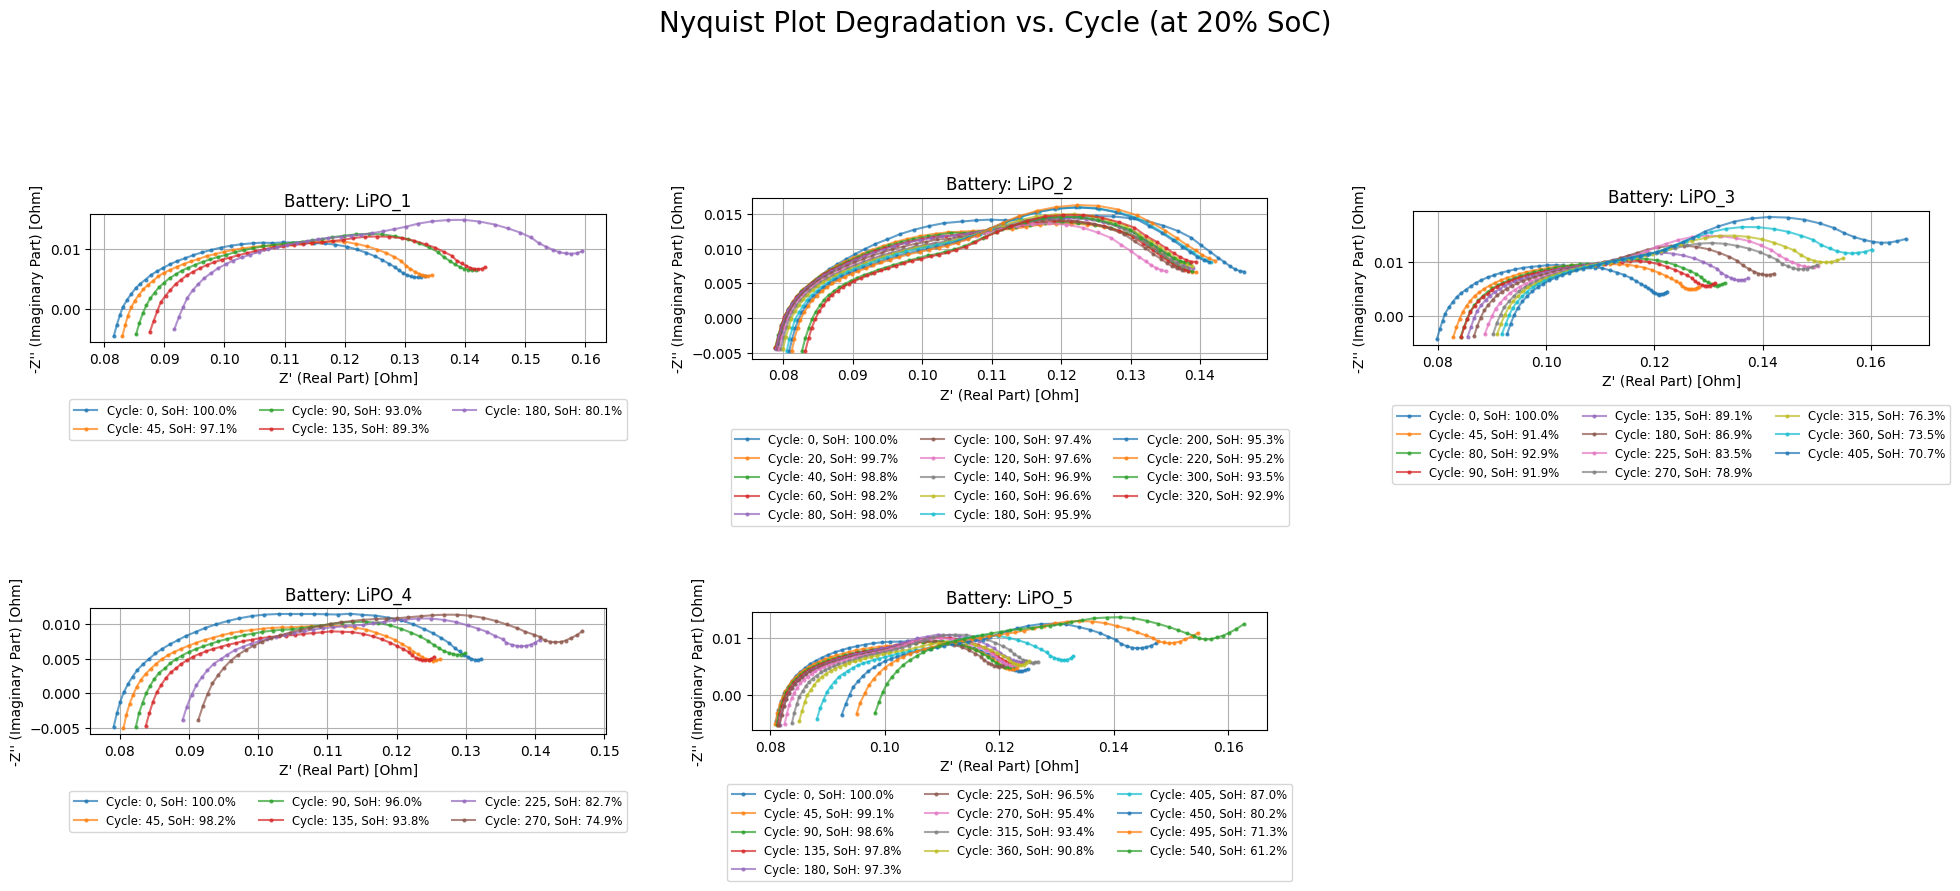

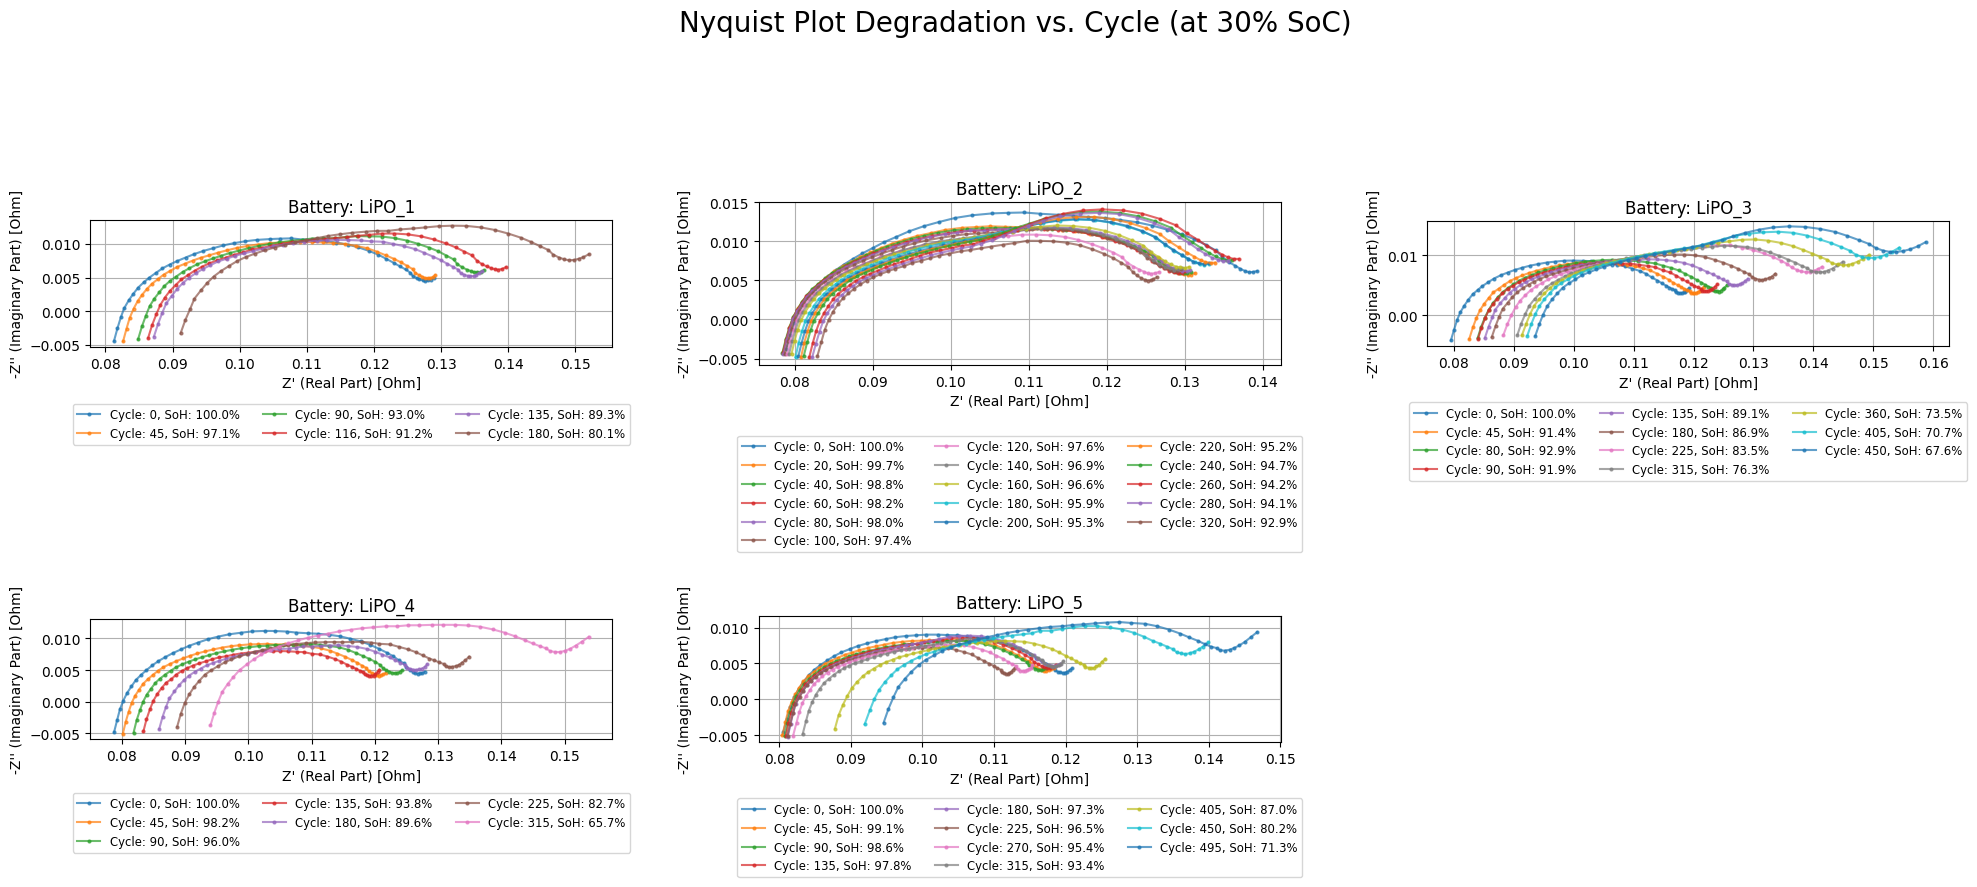

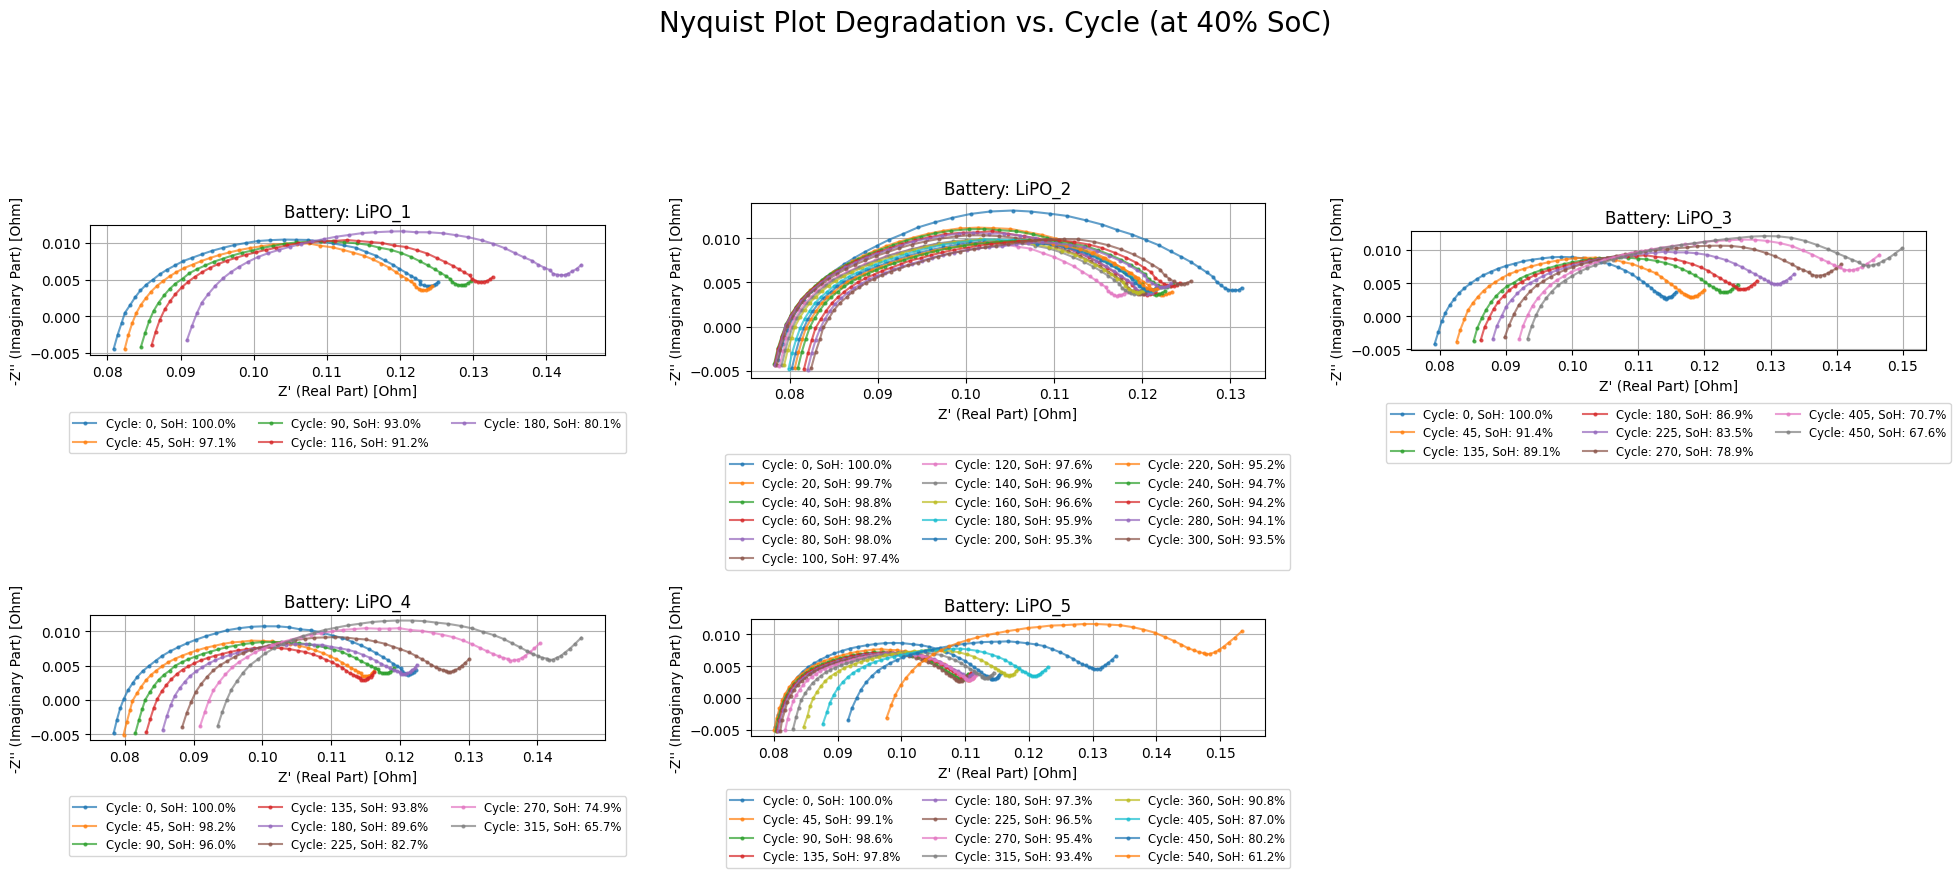

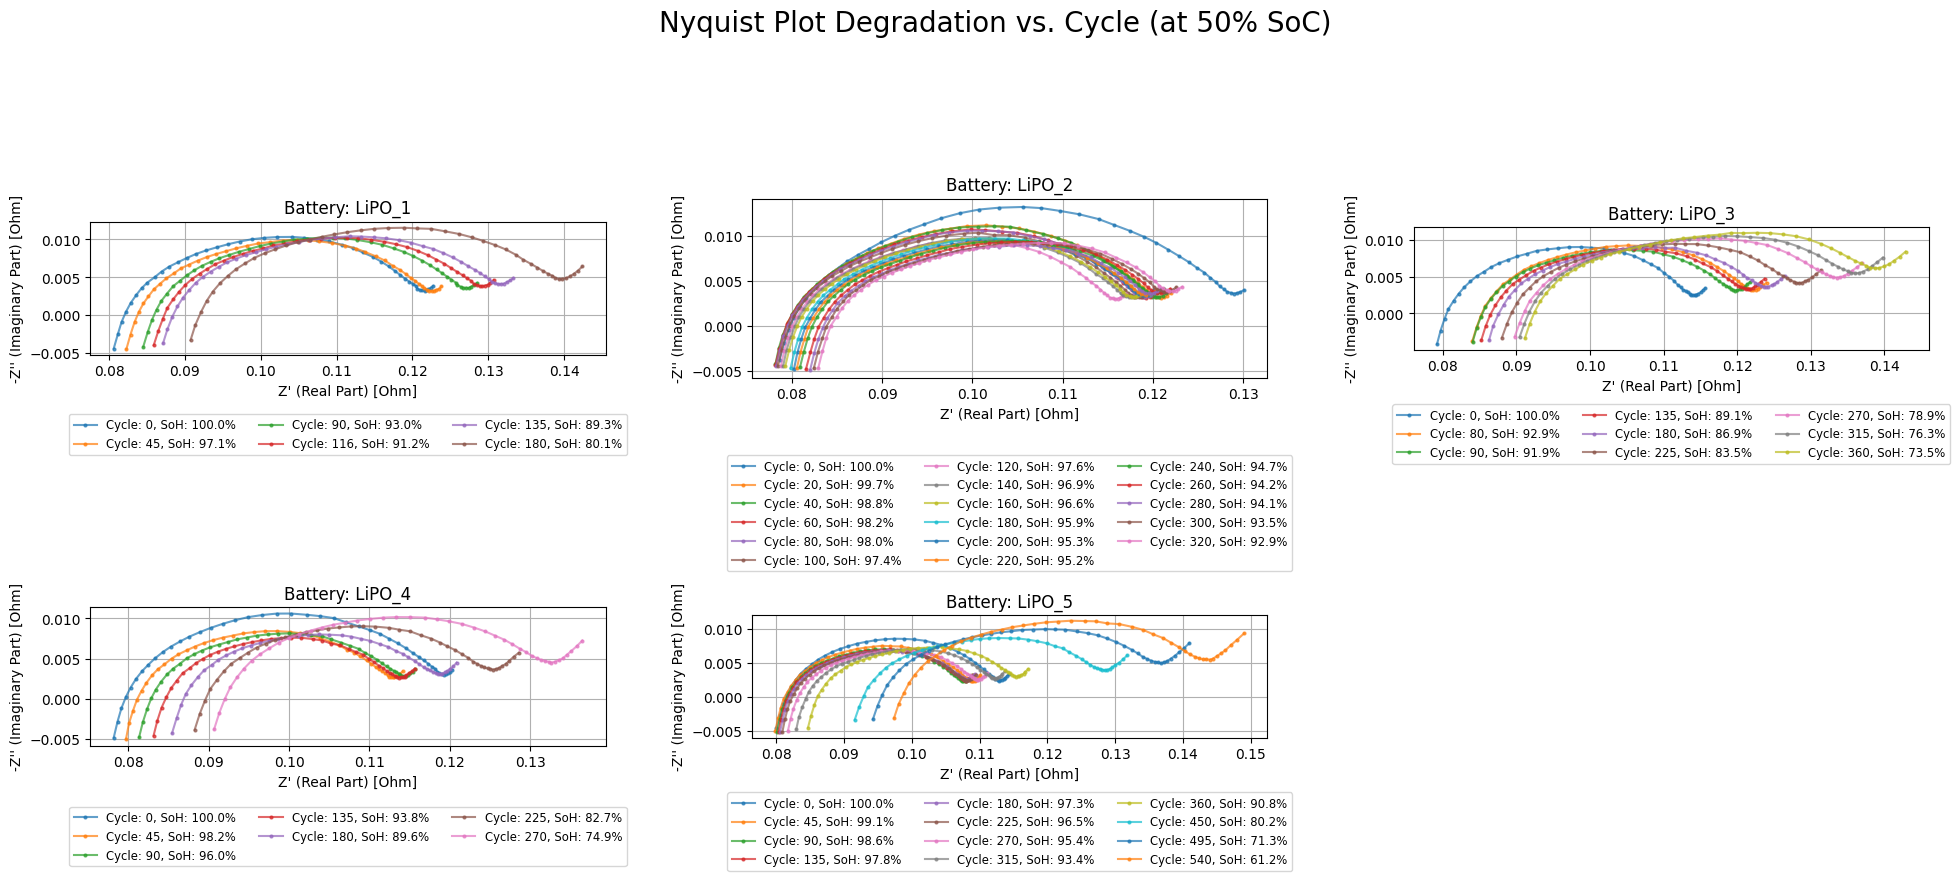

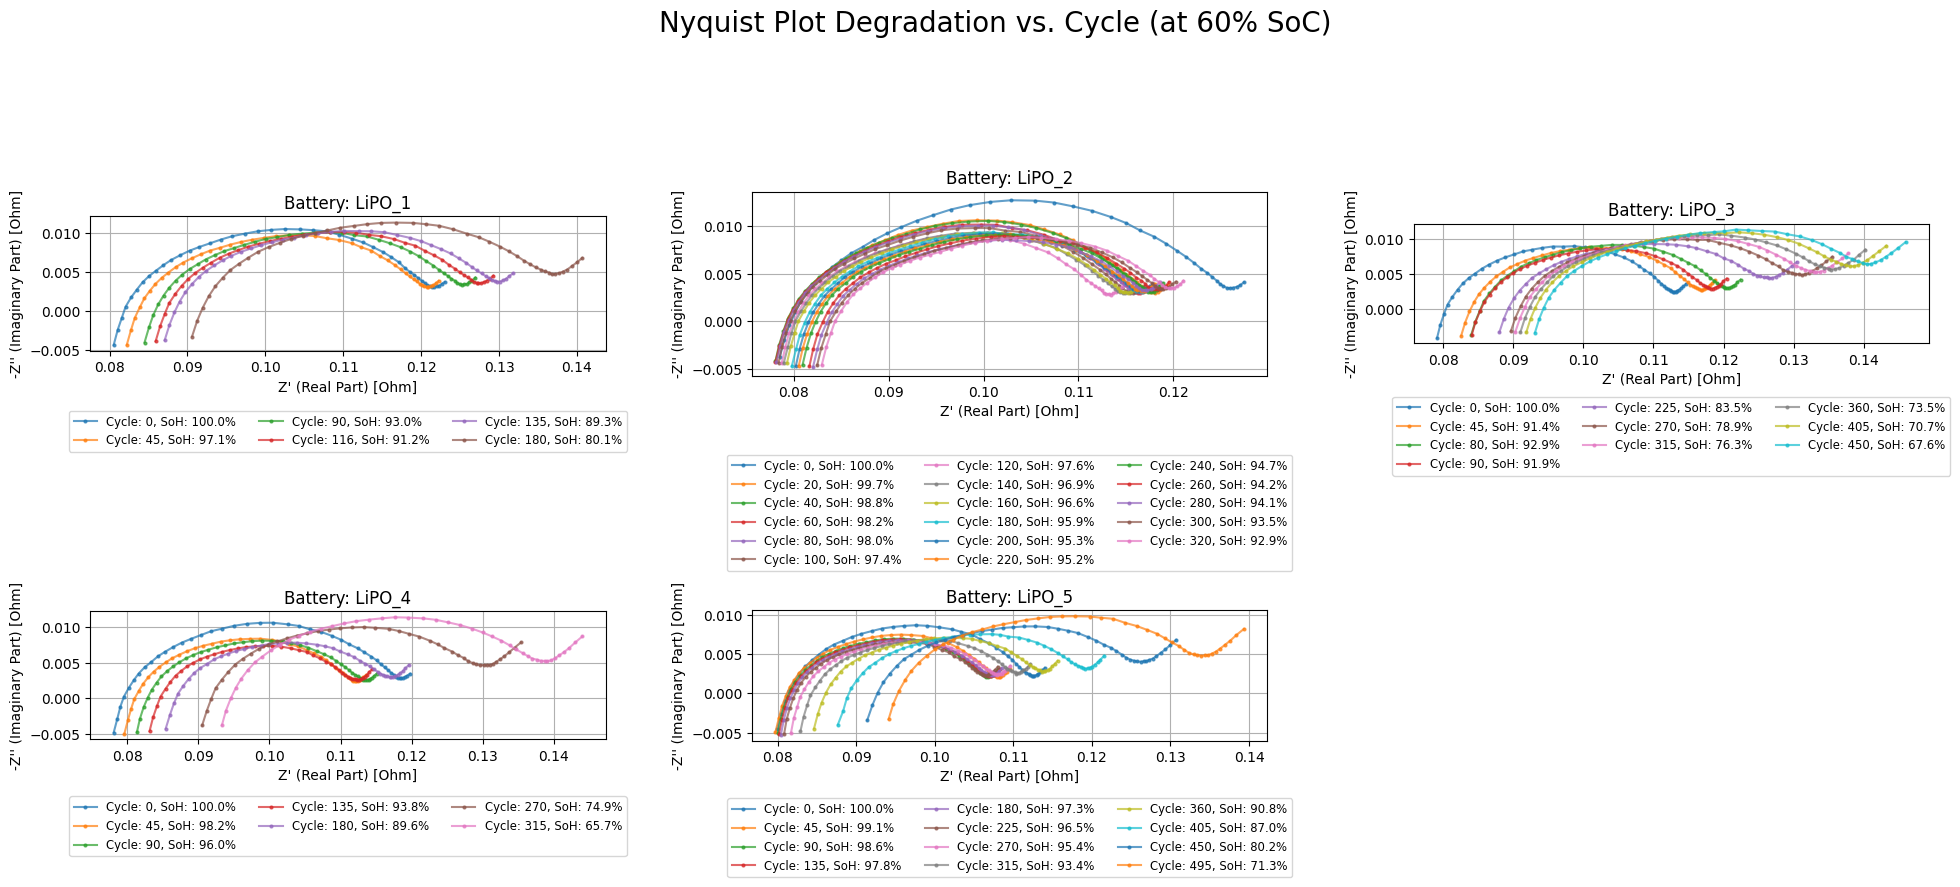

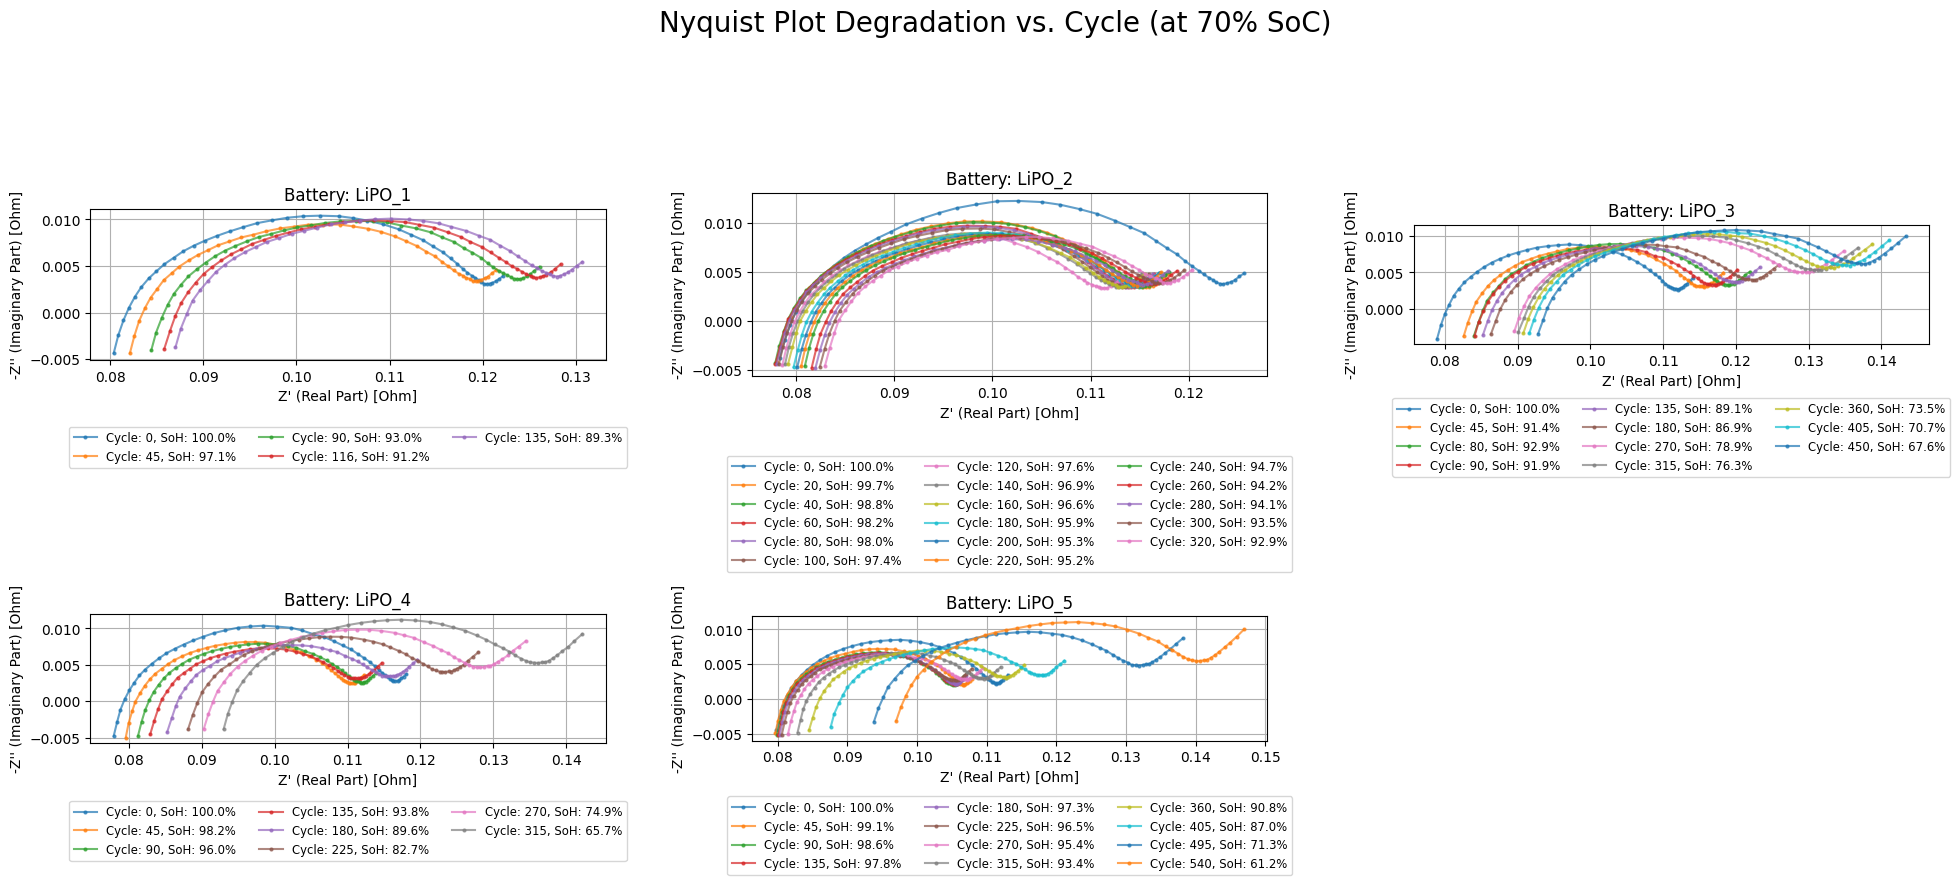

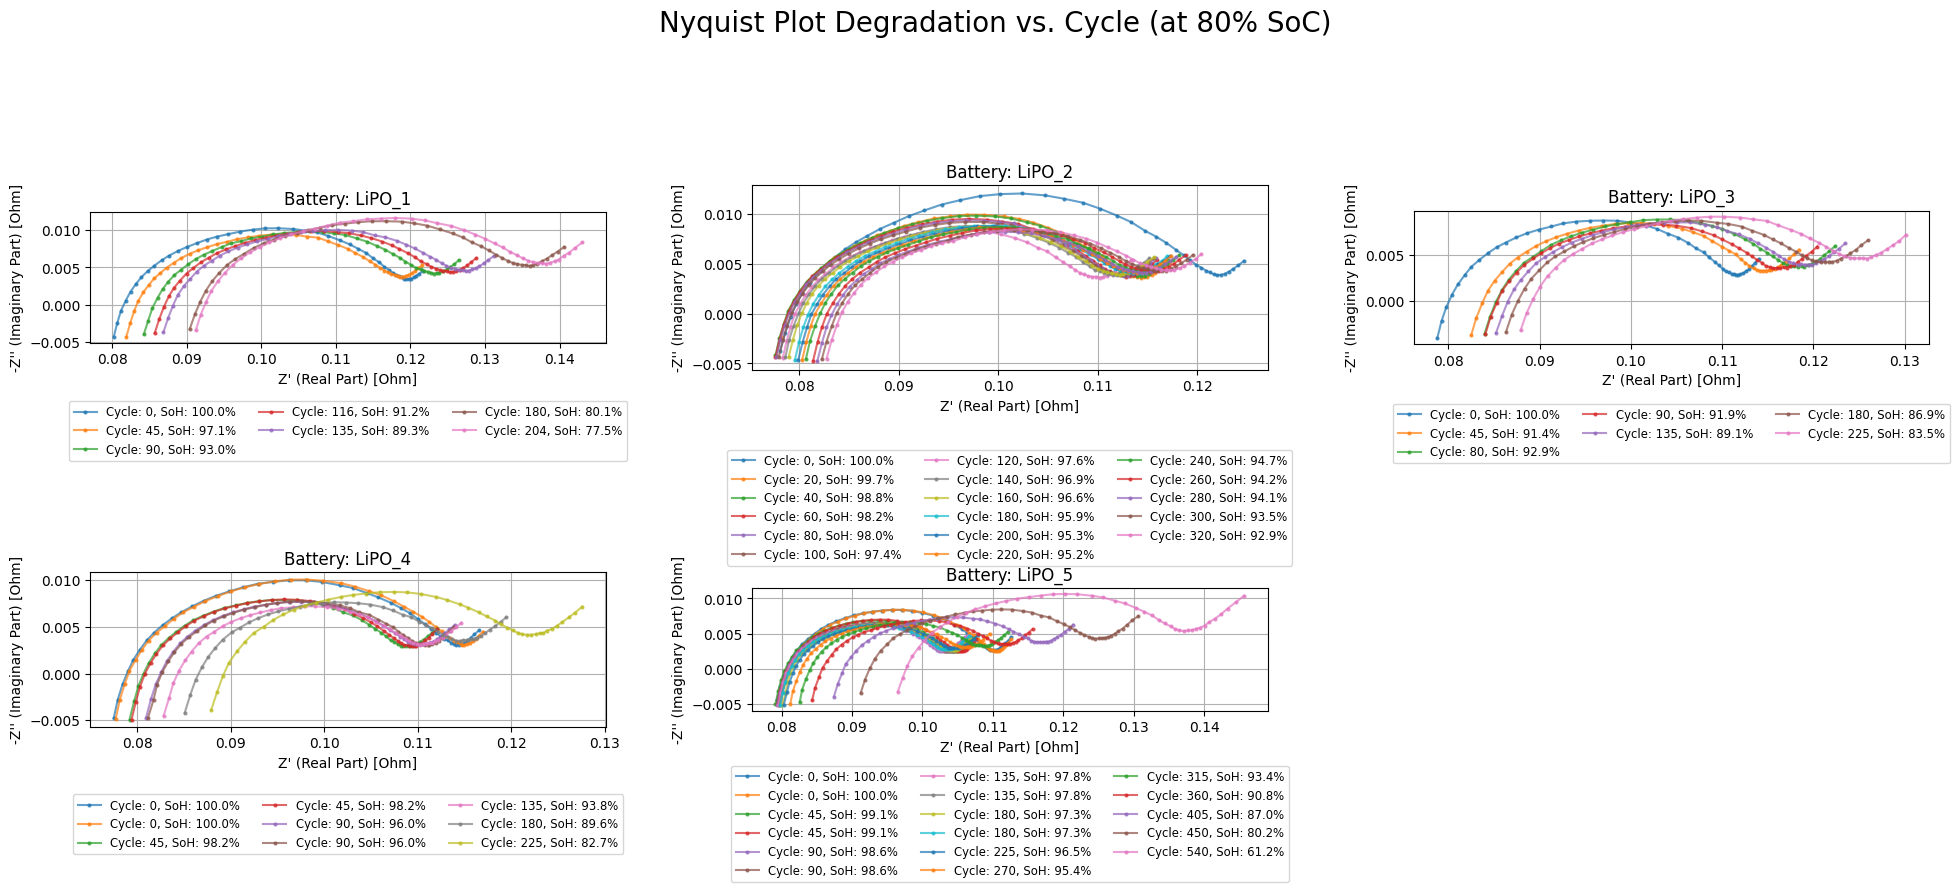

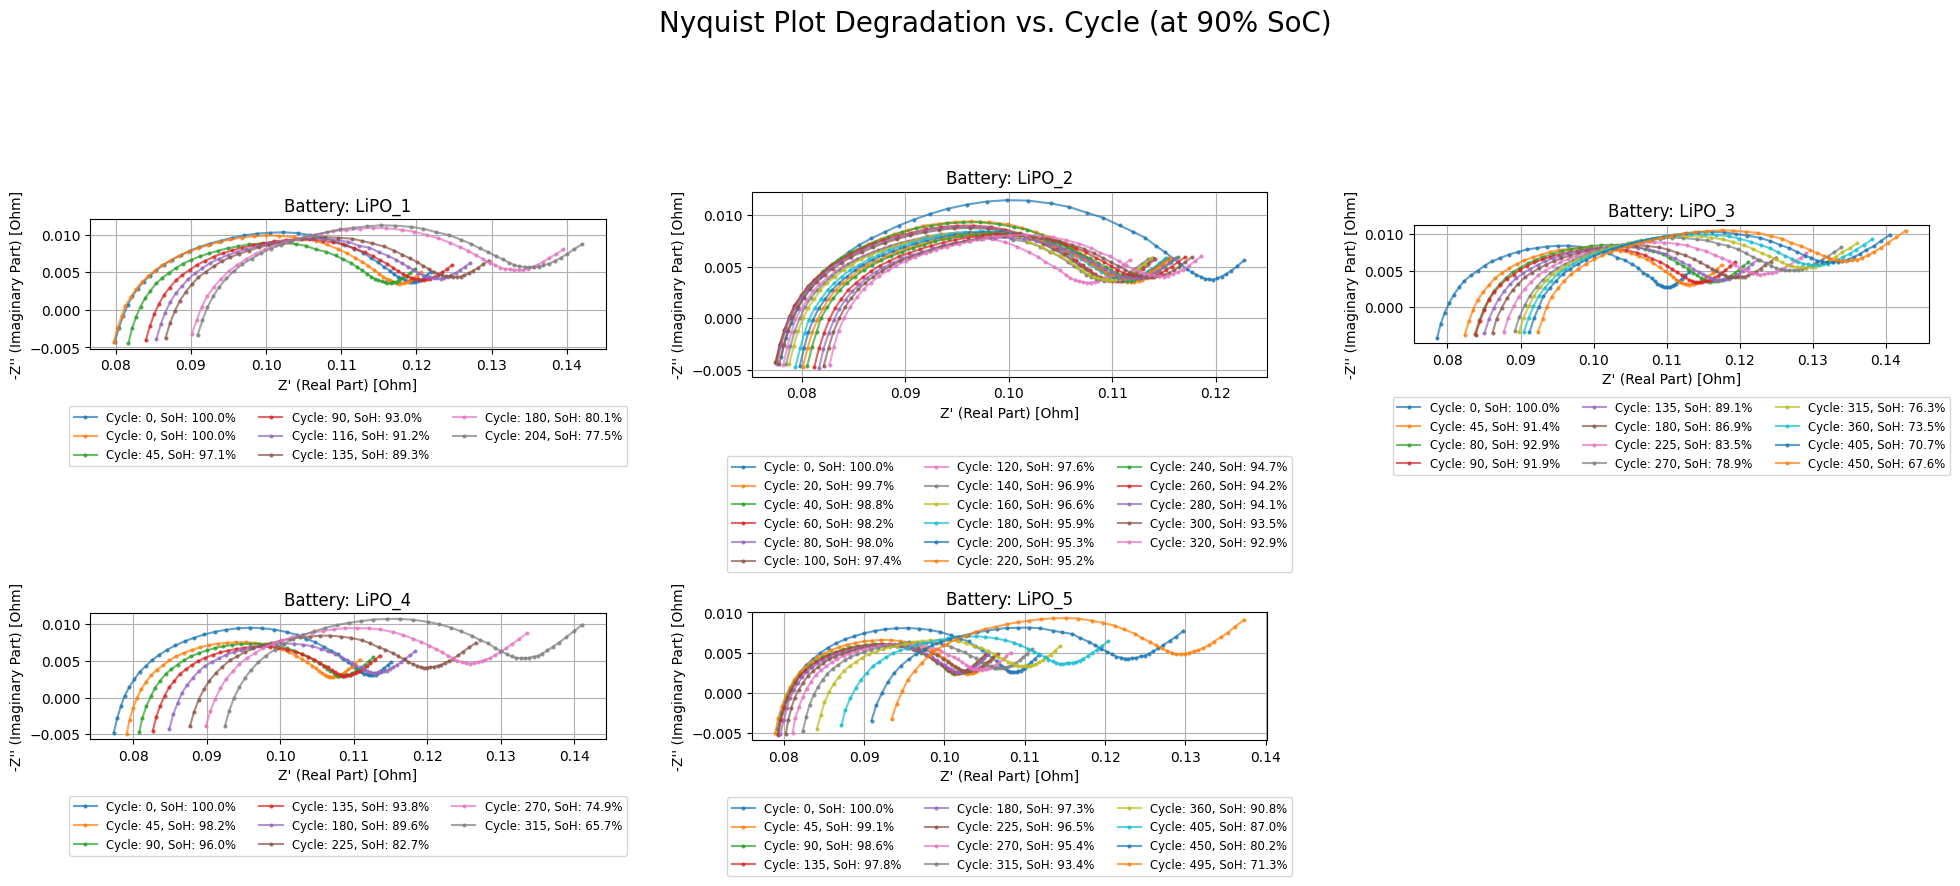

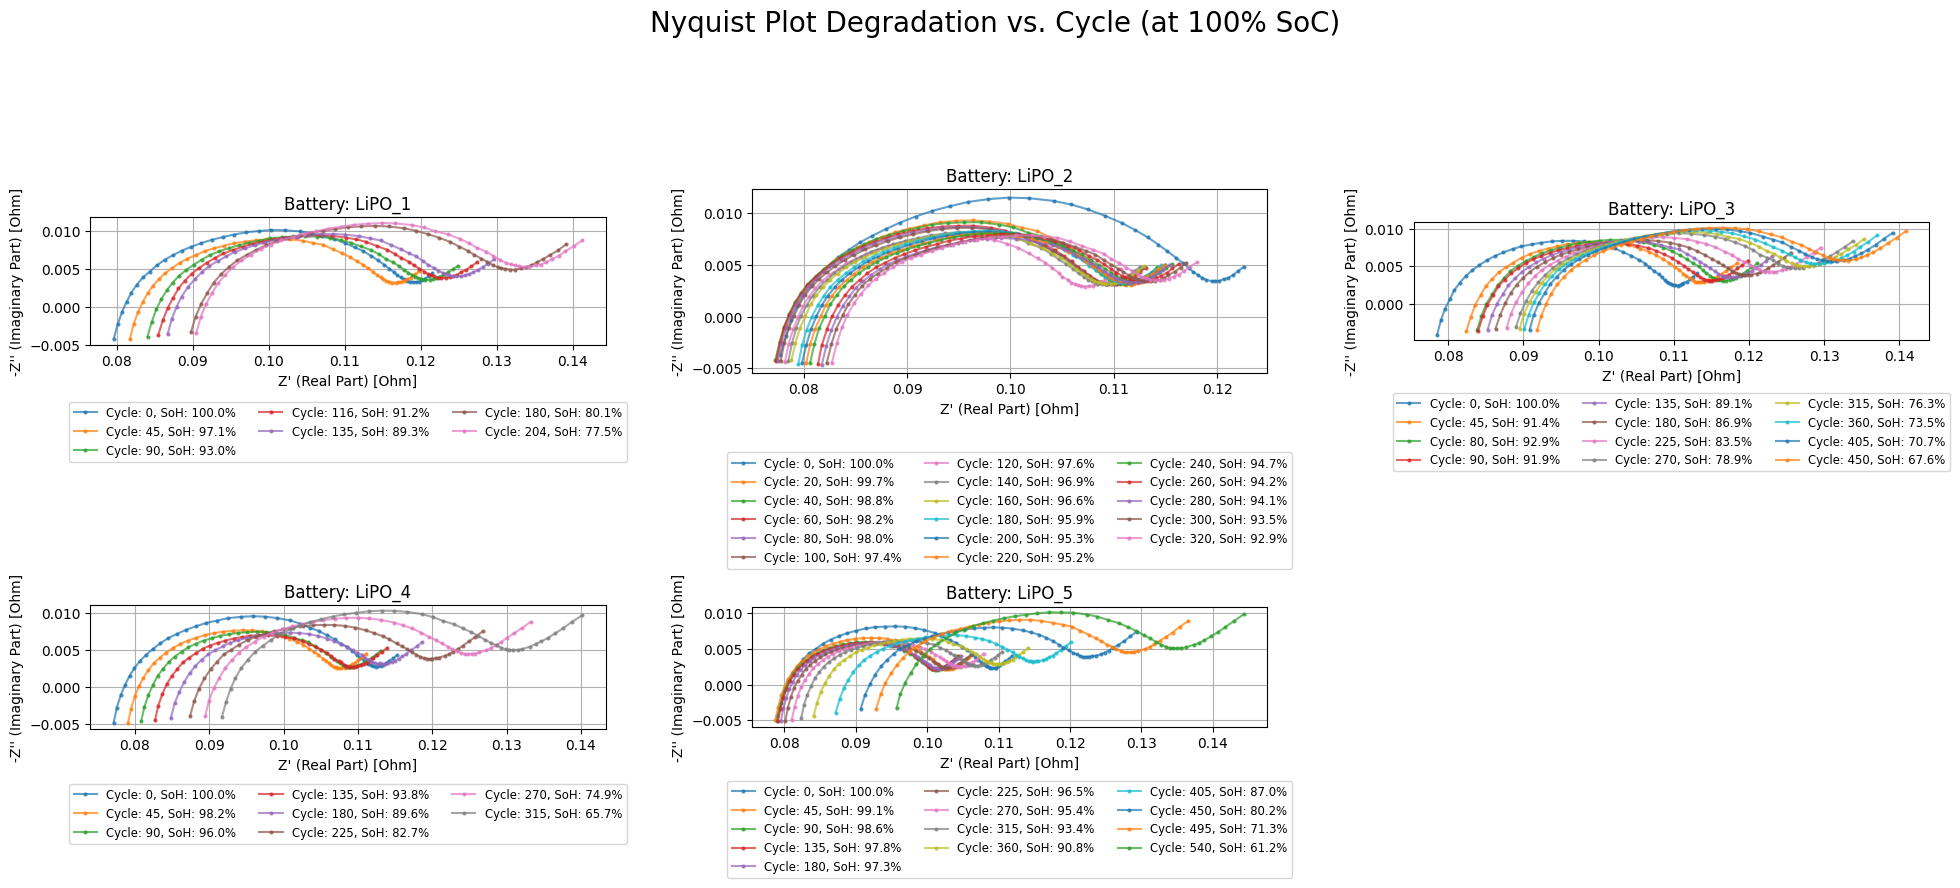

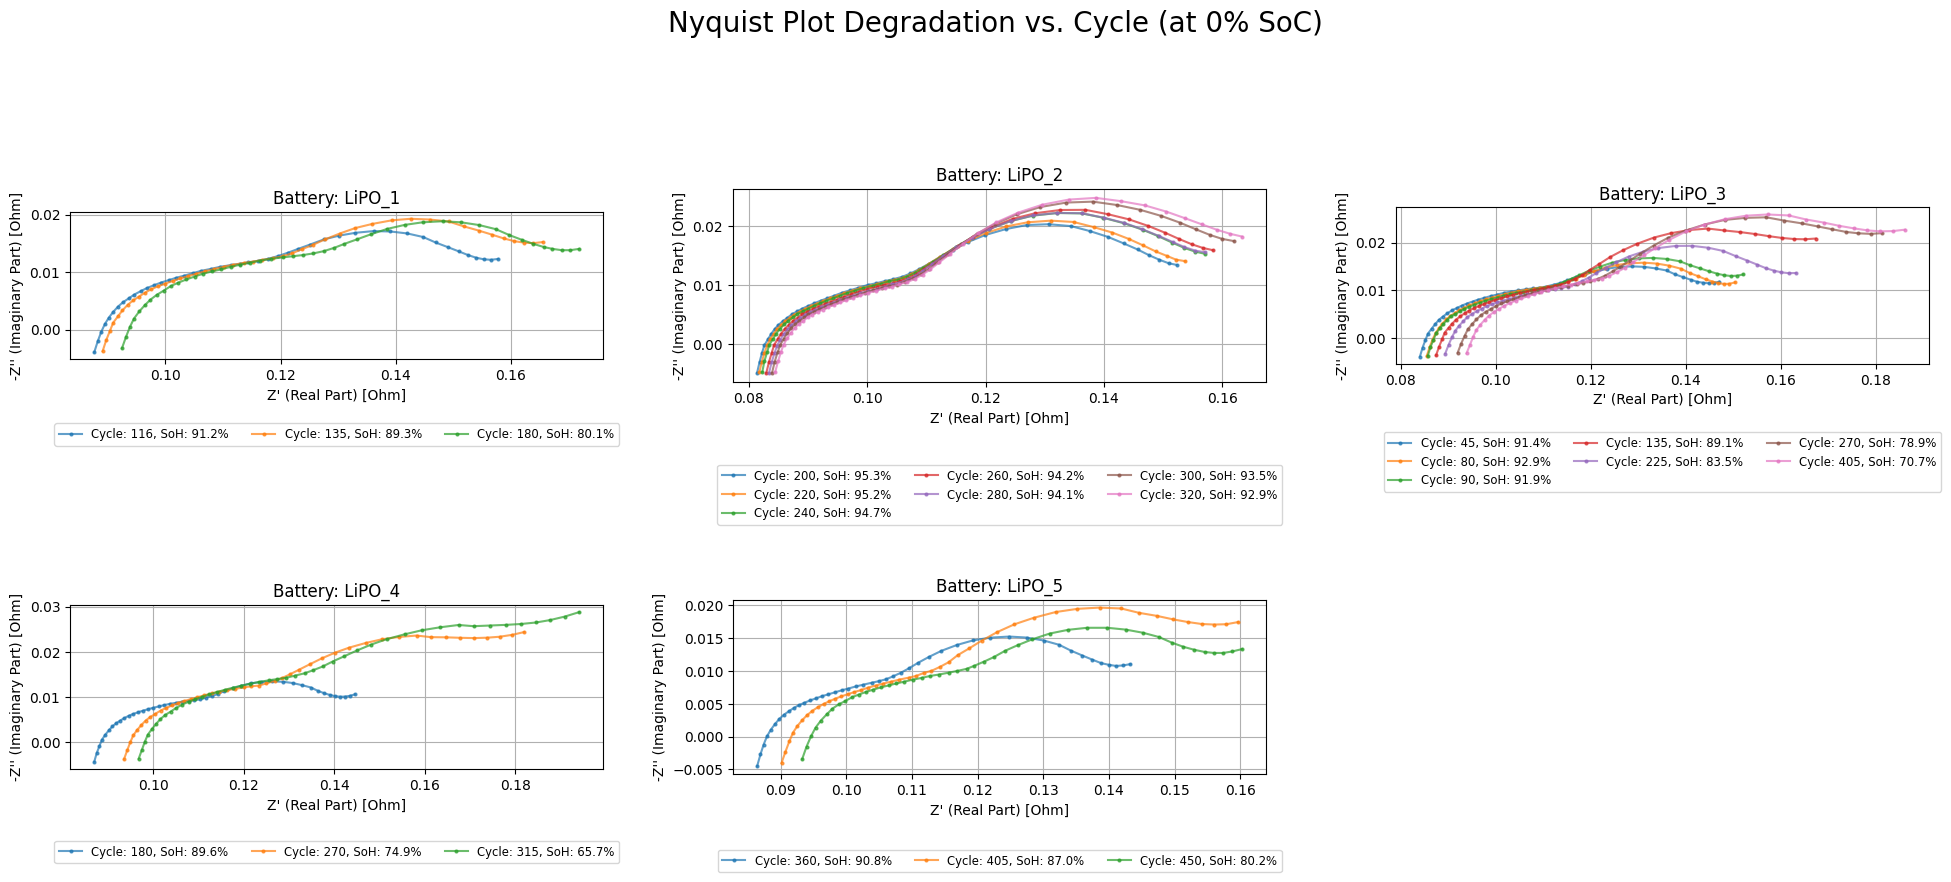

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import matplotlib.cm as cm  <-- No longer needed

col_names = ['Frequency(Hz)', 'R(ohm)', 'X(ohm)']

# --- 1. Outer Loop: Create one new FIGURE for each SoC ---
for soc in SoC_cohorts:
    
    # --- 2. Create the "Superstructure" Grid ---
    num_batteries = len(batteries)
    nrows = 2
    ncols = 3
    
    fig, axs = plt.subplots(nrows, ncols, figsize=(20, 10))
    ax_list = axs.flatten() # Easy to index this 1D list

    # --- 3. Inner Loop: Create one SUBPLOT for each Battery ---
    for i, battery in enumerate(batteries):
        
        # Select the correct subplot for this battery
        ax = ax_list[i]
        
        # --- 4. Get all data for this (Battery, SoC) combo ---
        cycle_data = all_battery_data[
            (all_battery_data["Modified SoC"] == soc) & 
            (all_battery_data["Battery"] == battery)
        ]
        
        # Sort by cycle to plot degradation in order
        cycle_data = cycle_data.sort_values(by='Cycle')
        
        if not cycle_data.empty:
            
            # --- 6. Innermost Loop: Plot ALL CYCLES ---
            for index, row in cycle_data.iterrows():
                
                eis_file_path = row['EIS_File']
                current_cycle = row['Cycle']
                current_soh = row['SoH']  # <-- Get the SoH value
                
                try:
                    df = pd.read_csv(eis_file_path, sep='\t', names=col_names)
                    
                    R = df['R(ohm)'].values 
                    X = df['X(ohm)'].values
                    Z = R + 1j * X
                    
                    # --- Create the label for the legend ---
                    label_text = f"Cycle: {current_cycle}, SoH: {current_soh*100:.1f}%"
                    
                    # --- Plot with the new label (color removed) ---
                    ax.plot(Z.real, -Z.imag, marker='o', ms=2, alpha=0.7, label=label_text)
                
                except FileNotFoundError:
                    print(f"Warning: File not found {eis_file_path}")
                except pd.errors.EmptyDataError:
                    print(f"Warning: Empty file {eis_file_path}")

            # --- 7. Customize each subplot ---
            ax.set_title(f'Battery: {battery}')
            ax.set_xlabel("Z' (Real Part) [Ohm]")
            ax.set_ylabel("-Z'' (Imaginary Part) [Ohm]")
            ax.set_aspect('equal') # "Confined in a box"
            ax.grid(True)

            # --- THIS IS THE MODIFIED LEGEND ---
            # Add a standard legend BELOW the subplot
            ax.legend(loc='upper center', 
                      bbox_to_anchor=(0.5, -0.4), # Places legend below the plot
                      ncol=3,                   # Arranges in 3 columns
                      fontsize='small')

    # --- 8. Clean up unused subplots ---
    for j in range(num_batteries, nrows * ncols):
        fig.delaxes(ax_list[j])
        
    # --- 9. Add the Superstructure Title ---
    fig.suptitle(f'Nyquist Plot Degradation vs. Cycle (at {soc*100:.0f}% SoC)', fontsize=20)
    
    # --- MODIFIED TIGHT_LAYOUT ---
    # Adjusted rect to make room at the bottom for the legends (bottom=0.1)
    plt.tight_layout(rect=[0, 0.1, 1, 0.95])
    plt.show()

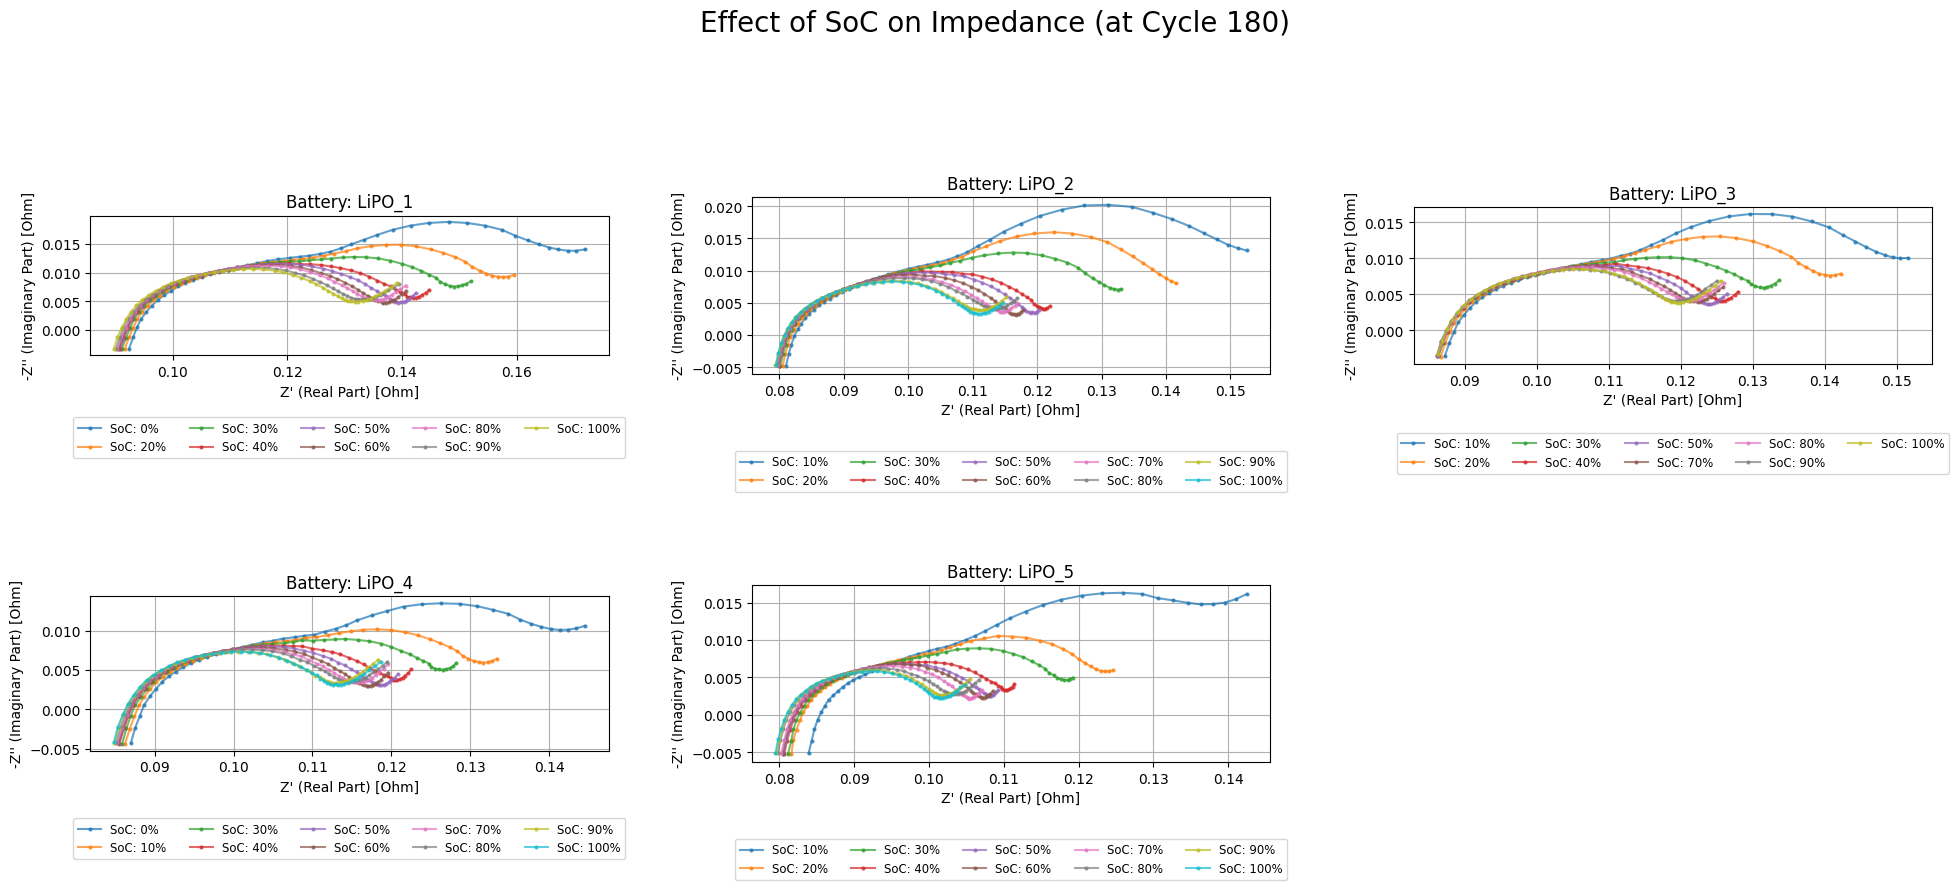

In [47]:
col_names = ['Frequency(Hz)', 'R(ohm)', 'X(ohm)']

# --- 1. Define which cycle you want to analyze ---
target_cycle = 180  # Change this to 50, 100, etc. to see the effect on aged batteries

# --- 2. Create the "Superstructure" Grid ---
# A 2x3 grid is good for 5 batteries
num_batteries = len(batteries)
nrows = 2
ncols = 3

# Create the figure; REMOVED sharex/sharey to allow different axes
fig, axs = plt.subplots(nrows, ncols, figsize=(20, 10))
ax_list = axs.flatten()  # Easy to index this 1D list

# --- 3. Outer Loop: Create one SUBPLOT for each Battery ---
for i, battery in enumerate(batteries):
    
    # Select the correct subplot for this battery
    ax = ax_list[i]
    
    # Sort cohorts to make the legend sequential
    sorted_SoC_cohorts = sorted(SoC_cohorts)
    
    # --- 4. Inner Loop: Plot ALL SoCs for the target cycle ---
    for soc in sorted_SoC_cohorts:
        
        # --- 5. Get data for this (Battery, SoC, AND Cycle) combo ---
        eis_data = all_battery_data[
            (all_battery_data["Modified SoC"] == soc) & 
            (all_battery_data["Battery"] == battery) &
            (all_battery_data["Cycle"] == target_cycle)  # <-- Filtering for the target cycle
        ]
        
        # This assumes one unique file for the combo
        if not eis_data.empty:
            
            eis_file_path = eis_data.iloc[0]['EIS_File']
            
            try:
                df = pd.read_csv(eis_file_path, sep='\t', names=col_names)
                
                R = df['R(ohm)'].values 
                X = df['X(ohm)'].values
                Z = R + 1j * X
                
                # Create the label for the legend
                label_text = f"SoC: {soc*100:.0f}%" 
                
                # Plot this SoC's Nyquist data
                ax.plot(Z.real, -Z.imag, marker='o', ms=2, alpha=0.7, label=label_text)
            
            except FileNotFoundError:
                print(f"Warning: File not found {eis_file_path}")
            except pd.errors.EmptyDataError:
                print(f"Warning: Empty file {eis_file_path}")

    # --- 6. Customize each subplot ---
    ax.set_title(f'Battery: {battery}')
    ax.set_xlabel("Z' (Real Part) [Ohm]")
    ax.set_ylabel("-Z'' (Imaginary Part) [Ohm]")
    ax.set_aspect('equal')  # "Confined in a box"
    ax.grid(True)

    # --- Add a standard legend BELOW the subplot ---
    # Adjust 'ncol' based on how many SoCs you have
    ax.legend(loc='upper center', 
              bbox_to_anchor=(0.5, -0.4),  # Places legend below the plot
              ncol=5,                    # Arranges in 5 columns (adjust as needed)
              fontsize='small')

# --- 7. Clean up unused subplots ---
for j in range(num_batteries, nrows * ncols):
    fig.delaxes(ax_list[j])
    
# --- 8. Add the Superstructure Title ---
fig.suptitle(f'Effect of SoC on Impedance (at Cycle {target_cycle})', fontsize=20)

# --- 9. Adjust layout ---
# Adjusted rect to make room at the bottom for the legends (bottom=0.1)
plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()

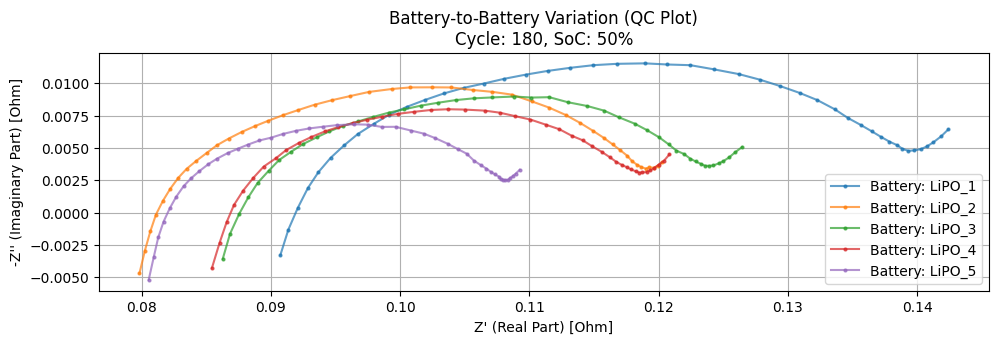

In [44]:
col_names = ['Frequency(Hz)', 'R(ohm)', 'X(ohm)']

# --- 1. Define which Cycle and SoC you want to compare ---
target_cycle = 180   # e.g., 1 (for new) or 100 (for aged)
target_soc = 0.5   # e.g., 0.5 (for 50% SoC)

# --- 2. Create ONE single plot (figure and axis) ---
fig, ax = plt.subplots(figsize=(10, 8))

# --- 3. Loop through each battery and plot on the SAME axis ---
for battery in batteries:
    
    # --- 4. Get data for this (Battery, SoC, AND Cycle) combo ---
    eis_data = all_battery_data[
        (all_battery_data["Modified SoC"] == target_soc) & 
        (all_battery_data["Battery"] == battery) &
        (all_battery_data["Cycle"] == target_cycle)
    ]
    
    # This assumes one unique file for the combo
    if not eis_data.empty:
        
        eis_file_path = eis_data.iloc[0]['EIS_File']
        
        try:
            df = pd.read_csv(eis_file_path, sep='\t', names=col_names)
            
            R = df['R(ohm)'].values 
            X = df['X(ohm)'].values
            Z = R + 1j * X
            
            # --- Plot on the single 'ax' object ---
            ax.plot(Z.real, -Z.imag, marker='o', ms=2, alpha=0.7, label=f'Battery: {battery}')
        
        except FileNotFoundError:
            print(f"Warning: File not found {eis_file_path}")
        except pd.errors.EmptyDataError:
            print(f"Warning: Empty file {eis_file_path}")

# --- 5. Customize the single plot ---
ax.set_title(f'Battery-to-Battery Variation (QC Plot)\nCycle: {target_cycle}, SoC: {target_soc*100:.0f}%')
ax.set_xlabel("Z' (Real Part) [Ohm]")
ax.set_ylabel("-Z'' (Imaginary Part) [Ohm]")
ax.set_aspect('equal')  # "Confined in a box"
ax.grid(True)

# Add a legend to distinguish the batteries
ax.legend(fontsize='medium')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

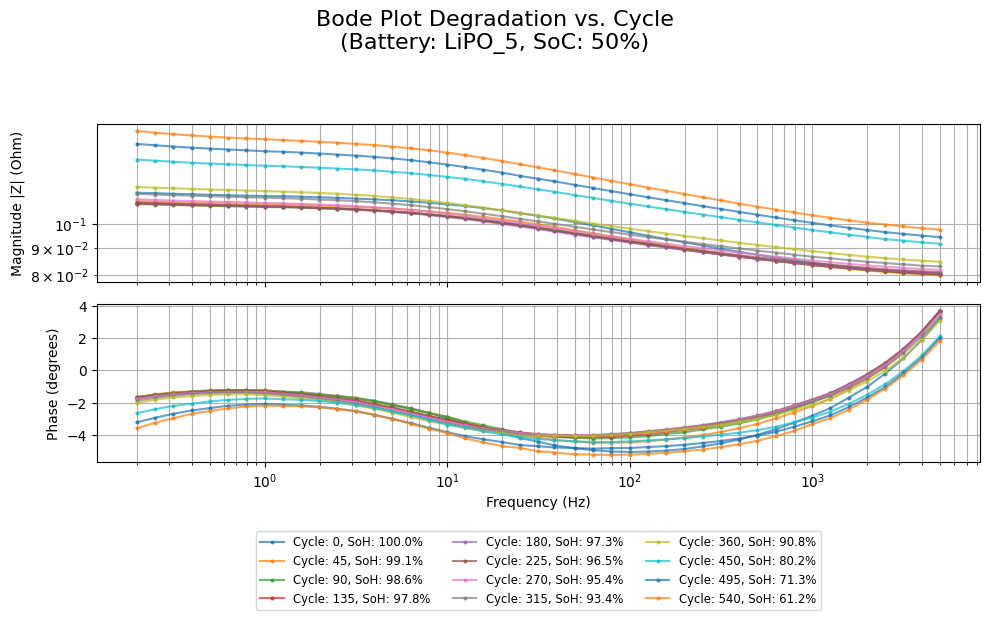

In [50]:
col_names = ['Frequency(Hz)', 'R(ohm)', 'X(ohm)']

# --- 1. Define which Battery and SoC you want to analyze ---
target_battery = batteries[4]  # Change this to any battery, e.g., 'LiPO_1'
target_soc = 0.5               # Change this to your desired SoC cohort, e.g., 0.9

# --- 2. Create the Figure with 2 subplots (Mag, Phase) ---
# sharex=True links the frequency axis for both plots
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax_mag = axs[0]   # Top plot for Magnitude
ax_phase = axs[1] # Bottom plot for Phase

# --- 3. Get all data for this (Battery, SoC) combo ---
cycle_data = all_battery_data[
    (all_battery_data["Modified SoC"] == target_soc) & 
    (all_battery_data["Battery"] == target_battery)
]

# Sort by cycle to plot degradation in order
cycle_data = cycle_data.sort_values(by='Cycle')

if not cycle_data.empty:
    
    # --- 4. Innermost Loop: Plot ALL CYCLES ---
    for index, row in cycle_data.iterrows():
        
        eis_file_path = row['EIS_File']
        current_cycle = row['Cycle']
        current_soh = row['SoH']
        
        try:
            df = pd.read_csv(eis_file_path, sep='\t', names=col_names)
            
            f_x = df['Frequency(Hz)'].values
            R = df['R(ohm)'].values 
            X = df['X(ohm)'].values
            Z = R + 1j * X
            
            # Create the label for the legend
            label_text = f"Cycle: {current_cycle}, SoH: {current_soh*100:.1f}%"
            
            # --- 5. Plot on the two subplots ---
            
            # Plot Magnitude (|Z|) on a log-log scale
            ax_mag.loglog(f_x, np.abs(Z), marker='o', ms=2, alpha=0.7, label=label_text)
            
            # Plot Phase (degrees) on a semilog-x scale
            ax_phase.semilogx(f_x, np.angle(Z, deg=True), marker='o', ms=2, alpha=0.7, label=label_text)
        
        except FileNotFoundError:
            print(f"Warning: File not found {eis_file_path}")
        except pd.errors.EmptyDataError:
            print(f"Warning: Empty file {eis_file_path}")

# --- 6. Customize the plots ---
ax_mag.set_ylabel('Magnitude |Z| (Ohm)')
ax_mag.grid(True, which='both') # 'which=both' adds minor gridlines for log scale

ax_phase.set_xlabel('Frequency (Hz)')
ax_phase.set_ylabel('Phase (degrees)')
ax_phase.grid(True, which='both')

# --- Add the row-wise legend BELOW the bottom plot ---
ax_phase.legend(loc='upper center', 
              bbox_to_anchor=(0.5, -0.4), # Places legend below the plot
              ncol=3,                   # Adjust as needed
              fontsize='small')

# --- 7. Add the Main Title ---
fig.suptitle(f'Bode Plot Degradation vs. Cycle\n(Battery: {target_battery}, SoC: {target_soc*100:.0f}%)', fontsize=16)

# --- 8. Adjust layout ---
# Adjusted rect to make room at the bottom for the legend (bottom=0.15)
plt.tight_layout(rect=[0, 0.15, 1, 0.93])
plt.show()

# EIS Fitting Results

In [70]:
circuit,initial_guess = 'R1-p(CPE2,R2-Wo3)-W1',[
    0.1,      # R1
    1e-5,     # CPE2_T
    0.9,      # CPE2_P
    200,      # R2
    1.0,      # Wd3_R
    1e-5,     # Wd3_T    # W1_R
    1e-5      # W1_T
]
circuit,initial_guess = 'L1-R0-p(R1,CPE1)-W1',[0.1,0.1, 50, 1e-5, 0.9, 1] 
# changes

circuit_model = CustomCircuit(initial_guess=initial_guess, circuit=circuit)

In [ ]:
parameter_results = []

print("Fitting EIS models to all experiments...")
for index, row_data in tqdm(all_battery_data.iterrows(), 
                            total=len(all_battery_data), 
                            desc="Fitting EIS Models"):
    
    f = row_data['EIS_File']
    
    try:
        df = pd.read_csv(f, sep='\t', names=col_names)
        R = df['R(ohm)'].values 
        X = df['X(ohm)'].values
        Z = R + 1j * X
        
        circuit_model.fit(df['Frequency(Hz)'].values, Z)
        
        param_names = circuit_model.get_param_names()[0]
        param_values = circuit_model.parameters_
        
        param_dict = dict(zip(param_names, param_values))
        parameter_results.append(param_dict)
        
    except FileNotFoundError:
        tqdm.write(f"Warning: File not found {f}") 
        parameter_results.append({})
    except Exception as e:
        tqdm.write(f"Warning: Fit failed for file {f}. Error: {e}")
        parameter_results.append({})

param_df = pd.DataFrame(parameter_results, index=all_battery_data.index)

all_battery_data_EIS = pd.concat([all_battery_data, param_df], axis=1)

print("\nSuccessfully created new DataFrame with fitted parameters:")
all_battery_data_EIS.head()

Fitting EIS models to all experiments...


Fitting EIS Models: 100%|██████████| 549/549 [03:41<00:00,  2.48it/s]


Successfully created new DataFrame with fitted parameters:
  Battery  Cycle                                           EIS_File       SoC  \
5  LiPO_1      0  ./LiPo Battery LP-503562-IS-3 EIS, Capacity, E...  0.102017   
9  LiPO_1      0  ./LiPo Battery LP-503562-IS-3 EIS, Capacity, E...  0.199689   
8  LiPO_1      0  ./LiPo Battery LP-503562-IS-3 EIS, Capacity, E...  0.297359   
3  LiPO_1      0  ./LiPo Battery LP-503562-IS-3 EIS, Capacity, E...  0.395031   
2  LiPO_1      0  ./LiPo Battery LP-503562-IS-3 EIS, Capacity, E...  0.492432   

   Discharge_Capacity_Ah  SoH  Modified SoC            L1        R0        R1  \
5               3.664491  1.0           0.1  2.529651e-07  0.077352  0.084546   
9               3.664491  1.0           0.2  2.354031e-07  0.078058  0.059327   
8               3.664491  1.0           0.3  2.260028e-07  0.078475  0.052363   
3               3.664491  1.0           0.4  2.190703e-07  0.078716  0.047001   
2               3.664491  1.0           0.5  2.1

In [77]:
# all_battery_data_EIS.to_csv('all_battery_data_with_EIS_params.csv', index=False)
all_battery_data_EIS

,Battery,Cycle,EIS_File,SoC,Discharge_Capacity_Ah,SoH,Modified SoC,L1,R0,R1,CPE1_0,CPE1_1,W1
5,LiPO_1,0,"./LiPo Battery LP-503562-IS-3 EIS, Capacity, E...",0.102017,3.664491,1.000000,0.1,2.529651e-07,0.077352,0.084546,2.836881,0.375553,0.004130
9,LiPO_1,0,"./LiPo Battery LP-503562-IS-3 EIS, Capacity, E...",0.199689,3.664491,1.000000,0.2,2.354031e-07,0.078058,0.059327,1.590859,0.462267,0.001264
8,LiPO_1,0,"./LiPo Battery LP-503562-IS-3 EIS, Capacity, E...",0.297359,3.664491,1.000000,0.3,2.260028e-07,0.078475,0.052363,1.243498,0.498997,0.001800
3,LiPO_1,0,"./LiPo Battery LP-503562-IS-3 EIS, Capacity, E...",0.395031,3.664491,1.000000,0.4,2.190703e-07,0.078716,0.047001,0.976102,0.534210,0.002409
2,LiPO_1,0,"./LiPo Battery LP-503562-IS-3 EIS, Capacity, E...",0.492432,3.664491,1.000000,0.5,2.133020e-07,0.078881,0.043850,0.793705,0.562357,0.001992
...,...,...,...,...,...,...,...,...,...,...,...,...,...
543,LiPO_5,540,"./LiPo Battery LP-503562-IS-3 EIS, Capacity, E...",0.379624,2.250180,0.611831,0.4,2.147648e-07,0.093543,0.056730,0.985077,0.485223,0.007505
546,LiPO_5,540,"./LiPo Battery LP-503562-IS-3 EIS, Capacity, E...",0.534825,2.250180,0.611831,0.5,2.054199e-07,0.094308,0.049879,0.681445,0.536441,0.007419
545,LiPO_5,540,"./LiPo Battery LP-503562-IS-3 EIS, Capacity, E...",0.690026,2.250180,0.611831,0.7,2.020409e-07,0.094374,0.046149,0.560054,0.563479,0.008815
547,LiPO_5,540,"./LiPo Battery LP-503562-IS-3 EIS, Capacity, E...",0.845228,2.250180,0.611831,0.8,2.052440e-07,0.093897,0.043711,0.535899,0.569816,0.009883


## Old Code

     x   y
0    0  10
1   45   9
2   90   9
3  116   9
4  135   9
5  180   9
6  204   9


NameError: name 'results_df' is not defined

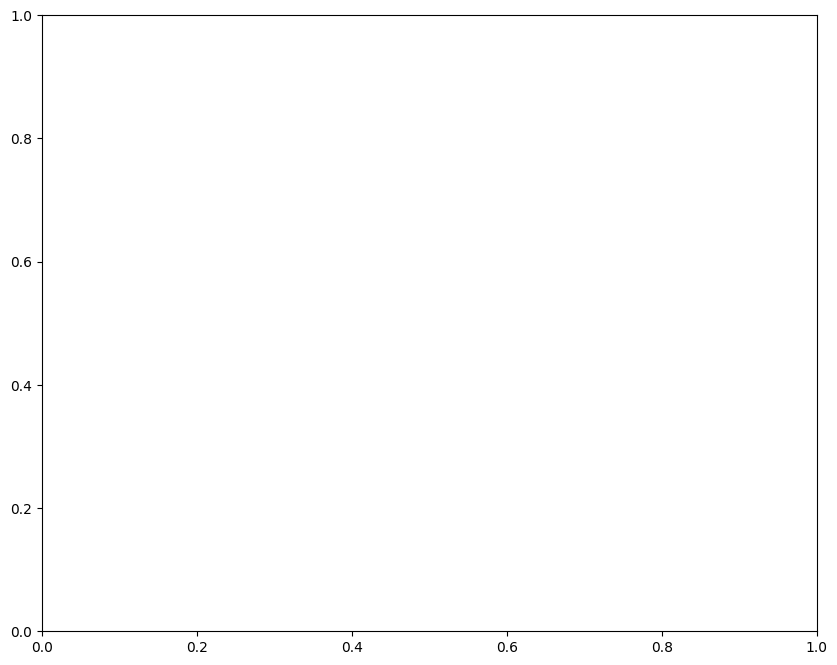

In [8]:
results_data = []

# File paths
soc = 10
filelist_path = f"/Users/sushankmishra/Desktop/MTP_Materials/EIS Fitting/LiPo Battery LP-503562-IS-3 EIS, Capacity, ECM Data/LiPO_1/EIS_Charge_discharge/soc_val/EISFiles_SoC{soc}.csv"
base_eis_path = "/Users/sushankmishra/Desktop/MTP_Materials/EIS Fitting/LiPo Battery LP-503562-IS-3 EIS, Capacity, ECM Data/LiPO_1/EIS_Charge_discharge/EIS_{x}/{y}_EIS.csv"

# Read the filelist.txt to get x and y values
filelist_df = pd.read_csv(filelist_path, header=None, names=['x', 'y'], delimiter='\t', index_col=False)
print(filelist_df)
# Initialize the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Loop through each row in the filelist
for _, row in filelist_df.iterrows():
    x = row['x']
    y = row['y']

    # Construct the EIS file path
    eis_file = base_eis_path.format(x=x, y=y)

    if os.path.exists(eis_file):
        df = pd.read_csv(eis_file, header=None, names=['Freq', 'Re', 'Im'], delimiter='\t')
        freq = df['Freq'].values
        Z_re = df['Re'].values
        Z_im = df['Im'].values

        # Fit the circuit model
        Z = Z_re + 1j * Z_im
        circuit_model.fit(freq, Z)

        # Get fitted parameters
        fitted_parameters = circuit_model.parameters_

        # Extract parameter names
        nested_param_names = circuit_model.get_param_names()
        param_names = [item for sublist in nested_param_names for item in (sublist if isinstance(sublist, list) else [sublist])]
        cycle_num = int(x)  # Assuming x corresponds to the cycle number
        soh = results_df.loc[cycle_num, 'SoH'] if cycle_num in results_df.index else None
        # Create a dictionary to store the row data
        row_data = {
            'SoC': soc,  # Assuming SoC is 90% for all files
            'Cycle': cycle_num,
            'SoH': soh
            # 'SoH': round(results_df.loc[cycle_num, 'SoH'], 2) if cycle_num in results_df.index else None
        }
        
        # Add circuit parameters to the row data
        for name, value in zip(param_names, fitted_parameters):
            row_data[name] = value

        # Append the row data to the results list
        results_data.append(row_data)

        # Plot using impedance-style: negative imaginary axis
        label = f"Cycle {cycle_num} - SoH {row_data['SoH']:.0%}" if row_data['SoH'] is not None else f"Cycle {cycle_num}"
        row_data['SoH'] = f"{row_data['SoH']:.0%}"  # Set SoC to 90% for all entries
        ax.plot(Z_re, -Z_im, label=label, linestyle='-', linewidth=2.5, marker='o')

# Customize the plot
ax.set_xlabel('Re(Z) [Ω]', fontsize=26, fontweight='bold')
ax.set_ylabel('-Im(Z) [Ω]', fontsize=26, fontweight='bold')
ax.set_title(f'EIS Spectra at SoC {soc}% with different SoH', fontsize=26, pad=20)
ax.tick_params(axis='both', which='major', labelsize=24)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')
ax.legend(fontsize=18)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()
# Convert results data to a DataFrame
results_new = pd.DataFrame(results_data)

# Save the results DataFrame to an Excel file
output_file = 'LiPo Battery LP-503562-IS-3 EIS, Capacity, ECM Data/LiPO_1/EIS_Charge_discharge/EIS_Fitting_Results.csv'

# Check if the file already exists
if not os.path.exists(output_file):
    # If the file doesn't exist, write the DataFrame with the header
    results_new.to_csv(output_file, index=False)
else:
    # If the file exists, append the data without writing the header
    results_new.to_csv(output_file, mode='a', index=False, header=False)

## Checking post neglect of less than 0 values of -Z_im

In [ ]:
# results_df.set_index('Cycle', inplace=True)
if results_df.index.name != 'Cycle':
    results_df.set_index('Cycle', inplace=True)
soc = list(range(10, 101, 10))
for soc in soc:
    results_data = []
    # print(f"Processing SoC: {soc}%")
    filelist_path = f"/Users/sushankmishra/Desktop/MTP_Materials/EIS Fitting/LiPo Battery LP-503562-IS-3 EIS, Capacity, ECM Data/LiPO_1/EIS_Charge_discharge/soc_val/EISFiles_SoC{soc}.csv"
    base_eis_path = "/Users/sushankmishra/Desktop/MTP_Materials/EIS Fitting/LiPo Battery LP-503562-IS-3 EIS, Capacity, ECM Data/LiPO_1/EIS_Charge_discharge/EIS_{x}/{y}_EIS.csv"

    # Read the filelist.txt to get x and y values
    filelist_df = pd.read_csv(filelist_path, header=None, names=['x', 'y'], delimiter='\t', index_col=False)
    # print(filelist_df)
    # Initialize the plot
    fig, ax = plt.subplots(figsize=(10, 8))

    # Loop through each row in the filelist
    for _, row in filelist_df.iterrows():
        x = row['x']
        y = row['y']

        # Construct the EIS file path
        eis_file = base_eis_path.format(x=x, y=y)

        if os.path.exists(eis_file):
            df = pd.read_csv(eis_file, header=None, names=['Freq', 'Re', 'Im'], delimiter='\t')
            # freq = df['Freq'].values
            # Z_re = df['Re'].values
            # Z_im = df['Im'].values
            
            freq = df['Freq'].values
            Z_re = df['Re'].values
            Z_im = df['Im'].values

            # Filter out values where Z_im < 0
            mask = Z_im >= 0
            freq = freq[~mask]
            Z_re = Z_re[~mask]
            Z_im = Z_im[~mask]

            # Fit the circuit model
            Z = Z_re + 1j * Z_im
            circuit_model.fit(freq, Z)

            # Get fitted parameters
            fitted_parameters = circuit_model.parameters_

            # Extract parameter names
            nested_param_names = circuit_model.get_param_names()
            param_names = [item for sublist in nested_param_names for item in (sublist if isinstance(sublist, list) else [sublist])]
            cycle_num = int(x)  # Assuming x corresponds to the cycle number
            soh = results_df.loc[cycle_num, 'SoH'] if cycle_num in results_df.index else None
            # Create a dictionary to store the row data
            row_data = {
                'SoC': soc,  # Assuming SoC is 90% for all files
                'Cycle': cycle_num,
                'SoH': soh
                # 'SoH': round(results_df.loc[cycle_num, 'SoH'], 2) if cycle_num in results_df.index else None
            }
            
            # Add circuit parameters to the row data
            for name, value in zip(param_names, fitted_parameters):
                row_data[name] = value

            # Append the row data to the results list
            results_data.append(row_data)

            # Plot using impedance-style: negative imaginary axis
            label = f"Cycle {cycle_num} - SoH {row_data['SoH']:.0%}" if row_data['SoH'] is not None else f"Cycle {cycle_num}"
            row_data['SoH'] = f"{row_data['SoH']:.0%}"  # Set SoC to 90% for all entries
            ax.plot(Z_re, -Z_im, label=label, linestyle='-', linewidth=2.5, marker='o')

    # Customize the plot
    ax.set_xlabel('Re(Z) [Ω]', fontsize=26, fontweight='bold')
    ax.set_ylabel('-Im(Z) [Ω]', fontsize=26, fontweight='bold')
    ax.set_title(f'EIS Spectra at SoC {soc}% with different SoH', fontsize=26, pad=20)
    ax.tick_params(axis='both', which='major', labelsize=24)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
    ax.legend(fontsize=18)
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)

    # Adjust layout and show the plot
    # plt.tight_layout()
    # plt.show()
    # Convert results data to a DataFrame
    results_new = pd.DataFrame(results_data)

    # Save the results DataFrame to an Excel file
    output_file = './EIS_Fitting_Results_new.csv'

    # Check if the file already exists
    if not os.path.exists(output_file):
        # If the file doesn't exist, write the DataFrame with the header
        results_new.to_csv(output_file, index=False)
    else:
        # If the file exists, append the data without writing the header
        results_new.to_csv(output_file, mode='a', index=False, header=False)

## Check Fitting of ECM on Data

In [ ]:
# File paths
soc = 90
cycle = 90  # <-- Set the cycle number you want to plot
filelist_path = f"/Users/sushankmishra/Desktop/MTP_Materials/EIS Fitting/LiPo Battery LP-503562-IS-3 EIS, Capacity, ECM Data/LiPO_1/EIS_Charge_discharge/soc_val/EISFiles_SoC{soc}.csv"
base_eis_path = "/Users/sushankmishra/Desktop/MTP_Materials/EIS Fitting/LiPo Battery LP-503562-IS-3 EIS, Capacity, ECM Data/LiPO_1/EIS_Charge_discharge/EIS_{x}/{y}_EIS.csv"

# Read the filelist to get x and y values
filelist_df = pd.read_csv(filelist_path, header=None, names=['x', 'y'], delimiter='\t', index_col=False)

# Define your circuit and initial guess
circuit = 'R0-p(R1-W1,CPE1)'
initial_guess = [0.1, 200, 1, 1e-5, 0.9]
circuit_model = CustomCircuit(initial_guess=initial_guess, circuit=circuit)
# Filter for the desired cycle
if cycle in filelist_df['x'].values:
    row = filelist_df[filelist_df['x'] == cycle].iloc[0]
    x = row['x']
    y = row['y']
    eis_file = base_eis_path.format(x=x, y=y)

    if os.path.exists(eis_file):
        df = pd.read_csv(eis_file, header=None, names=['Freq', 'Re', 'Im'], delimiter='\t')
        freq = df['Freq'].values
        Z_re = df['Re'].values
        Z_im = df['Im'].values

        # Fit the circuit model
        Z = Z_re + 1j * Z_im
        circuit_model.fit(freq, Z)
        Z_fit = circuit_model.predict(freq)
        print("Fitted Parameters:", circuit_model.parameters_)
        rmse = np.sqrt(np.mean(np.abs(Z - Z_fit) ** 2))
        print(f"Fitting RMSE for cycle {cycle}: {rmse:.4e} Ω")
        # Plot experimental and fitted data
        plt.figure(figsize=(7, 7))
        plt.plot(Z_re, -Z_im, 'o', label='Experimental', markersize=7)
        plt.plot(Z_fit.real, -Z_fit.imag, '-', label='Fitted', linewidth=2.5)
        plt.xlabel("Re(Z) [Ω]", fontsize=26, fontweight='bold')
        plt.ylabel("-Im(Z) [Ω]", fontsize=26, fontweight='bold')
        plt.title(f"Nyquist Plot: At SoC {soc}% for Cycle {x}", fontsize=20, fontweight='bold', pad=20)
        plt.tick_params(axis='both', which='major', labelsize=18)
        plt.legend(fontsize=18)
        plt.grid(True)
        for spine in plt.gca().spines.values():
            spine.set_linewidth(2.5)
        for label in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
            label.set_fontweight('bold')
        plt.tight_layout()
        plt.show()
    else:
        print(f"EIS file not found for cycle {cycle}")
else:
    print(f"Cycle {cycle} not found in filelist.")

## Tried & tested

In [ ]:
# Read the filelist.txt to get x and y values
filelist_df = pd.read_csv(filelist_path, header=None, names=['x', 'y'], delimiter='\t', index_col=False)
print(filelist_df)
# Initialize the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Loop through each row in the filelist
for _, row in filelist_df.iterrows():
    x = row['x']
    y = row['y']

    # Construct the EIS file path
    eis_file = base_eis_path.format(x=x, y=y)

    if os.path.exists(eis_file):
        # Load the EIS data
        df = pd.read_csv(eis_file, header=None, names=['Freq', 'Re', 'Im'], delimiter='\t', index_col=False)

        # Extract data for plotting
        freq = df['Freq'].values
        Z_re = df['Re'].values
        Z_im = df['Im'].values

        # Get SoH from earlier computed values (assuming results_df and cycle_num are defined)
        cycle_num = int(x)  # Assuming x corresponds to the cycle number
        soh = results_df.loc[cycle_num, 'SoH'] if cycle_num in results_df.index else None

        # Create label for the plot
        label = f"Cycle {cycle_num} - SoH {soh:.0%}" if soh is not None else f"Cycle {cycle_num}"

        # Plot using impedance-style: negative imaginary axis
        ax.plot(Z_re, -Z_im, label=label, linestyle='-', linewidth=2.5, marker='o')

# Customize the plot
ax.set_xlabel('Re(Z) [Ω]', fontsize=26, fontweight='bold')
ax.set_ylabel('-Im(Z) [Ω]', fontsize=26, fontweight='bold')
ax.set_title('EIS Spectra at SoC 90% with different SoH', fontsize=26, pad=20)
ax.tick_params(axis='both', which='major', labelsize=24)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')
ax.legend(fontsize=18)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()